## Baseline — Finger Tapping

Este notebook sigue el mismo flujo que `Prono-Supina.ipynb` pero adaptado a la prueba **Finger Tapping (MDS-UPDRS 3.4)**.

### Qué genera
- Métricas por archivo y por dispositivo (si hay LEFT/RIGHT)
- Gráficas detalladas por dispositivo
- Un `.json` con variables por prueba
- Un `.xlsx` con `raw_metrics` y `baseline_summary`

### Cómo correr
1. Ejecuta la celda **"Funciones"** (define todo el pipeline)
2. Ajusta `RUTA_ENTRADA` en la celda **"Ejecución"**
3. Ejecuta la celda **"Ejecución"**


## Funciones (pipeline)

Ejecuta esta celda para definir:
- Carga de `.json` (`imuData`)
- Separación por `deviceId`
- Remuestreo y filtrado
- Detección de taps (picos pos/neg + emparejamiento greedy)
- Extracción de métricas + gráficas
- Export a `.json` y `.xlsx`


In [1]:
"""
============================================================================
ANÁLISIS BASELINE COMPLETO: FINGER TAPPING CON DETECCIÓN MEJORADA
============================================================================
Propósito: Crear referencia de normalidad con detección robusta de taps
============================================================================
Basado en la prueba MDS-UPDRS ítem 3.4:
  - El paciente toca repetidamente el pulgar con el índice
  - Se evalúa: velocidad, amplitud, regularidad y decrementos
============================================================================
CORRECCIONES APLICADAS v2:
  1.  Remuestreo uniforme (interpolación a grilla FS constante)
  2.  Emparejamiento GREEDY BIDIRECCIONAL de taps (sin doble conteo,
      sin restricción de dirección temporal → mismo fix que pronación)
  3.  Estimación de apertura angular (integración trapezoidal de ω → grados)
  4.  Jerk angular (derivada de ω) y jerk lineal
  5.  FFT usa T=1/FS tras remuestreo (correcto)
  6.  Banda de paso adaptada a finger tapping (0.5–15 Hz)
  7.  Validación de FS real vs asumida
  8.  Filtro de alternancia conserva el pico de MAYOR amplitud
  9.  Detección de decremento ROBUSTO: regresión + percentiles robustos
       (resistente a hesitaciones y artefactos en bordes)
  10. Auto-detección de eje dominante por ENERGÍA REAL (no CV),
       selección separada para giroscopio y acelerómetro
  11. Eliminación de timestamps duplicados antes de interpolar
  12. [FIX NUEVO] seleccionar_top_n_picos: cuando se detectan más picos
       que ciclos esperados, conserva los de mayor amplitud absoluta
  13. [FIX NUEVO] ITI calculado desde taps_pareados (más robusto que
       solo picos_pos, funciona aunque el primer pico sea negativo)
  14. [FIX NUEVO] n_hesitaciones usa MEDIANA de ITI como referencia
       (robusta a outliers, no la media que se infla con pausas largas)
  15. [FIX NUEVO] compensacion_lateral usa los dos ejes que NO son
       el eje dominante (adaptativo, no hardcodeado a 'ay')
  16. [FIX NUEVO] N_CICLOS_ESPERADOS y USAR_TOP_N en ConfigBaseline
============================================================================
"""

import json
from pprint import pp
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
from scipy.fft import fft, fftfreq
from scipy.interpolate import interp1d
import os
from datetime import datetime
import pandas as pd


# ========================================
# 1. CONFIGURACIÓN GENERAL
# ========================================
class ConfigBaseline:
    """Configuración para análisis de baseline - FINGER TAPPING"""

    # Parámetros de filtrado
    FS = 100  # Frecuencia de muestreo objetivo [Hz]

    # Finger tapping: movimiento más rápido y con componente de impacto
    # ── CORRECCIÓN DE FILTROS ──
    # Se reduce el límite superior de los filtros (highcut).
    # El tapping real no suele superar los 4-6 Hz. Al dejar pasar hasta 15 Hz
    # se colaba el "ruido de impacto" (la vibración al chocar los dedos),
    # creando picos falsos y arruinando la detección.
    GYRO_LOWCUT = 0.5  # Hz (tapping normal ≥ 1 Hz; 0.5 captura bradikinesia severa)
    GYRO_HIGHCUT = 8.0  # Hz (Bajado de 15.0 a 8.0 para eliminar ruido de impacto)
    ACCEL_CUTOFF = (
        5.0  # Hz (Bajado de 10.0 a 5.0 para dejar solo el movimiento central)
    )

    # Detección de taps
    PICO_PROMINENCE_FACTOR = 0.03
    PICO_HEIGHT_FACTOR_POS = 0.03
    PICO_HEIGHT_FACTOR_NEG = 0.03
    PICO_MIN_DISTANCE = (
        10  # Subido de 3 a 10 (100 ms). Evita los dobles picos por rebotes.
    )
    PICO_WIDTH = (
        4  # Subido de 2 a 4. A 100Hz y filtro de 8Hz, el movimiento es más ancho.
    )

    # [FIX 16] Control de top-N picos (evita falsos positivos)
    N_CICLOS_ESPERADOS = 10  # Número exacto de taps del protocolo
    USAR_TOP_N = True  # Activar selección por top-N amplitudes

    # Umbrales para datos válidos (alineados con fingertapping_analisis_completo)
    CICLOS_MIN_VALIDOS = 6
    DURACION_MINIMA = 3.0  # segundos
    UMBRAL_HESITACION = 1.5  # ITI > 1.5 × mediana → hesitación

    # Tolerancia de FS real vs asumida
    FS_TOLERANCE = 0.20  # 20%

    # Carpetas
    OUTPUT_BASE = "./Finger Tapping/baseline"
    OUTPUT_INDIVIDUAL = "./Finger Tapping/baseline/individual"
    OUTPUT_SUMMARY = "./Finger Tapping/baseline/summary"


# ========================================
# 2. FUNCIONES DE DETECCIÓN DE PRUEBA
# ========================================
def detectar_tipo_prueba(archivo_path, imu_data):
    archivo_nombre = os.path.basename(archivo_path).lower()
    dispositivos = set()
    for dato in imu_data:
        if "deviceId" in dato:
            dispositivos.add(dato["deviceId"])

    if "right" in archivo_nombre or "derecha" in archivo_nombre:
        return "right_only", "Mano derecha única", list(dispositivos)
    elif "left" in archivo_nombre or "izquierda" in archivo_nombre:
        return "left_only", "Mano izquierda única", list(dispositivos)
    elif "both" in archivo_nombre or "ambas" in archivo_nombre:
        return "both_hands", "Ambas manos", list(dispositivos)
    elif len(dispositivos) == 1:
        return "single_hand", "Mano única (detectada)", list(dispositivos)
    elif len(dispositivos) > 1:
        return "both_hands", "Ambas manos (detectada)", list(dispositivos)
    else:
        return "unknown", "Tipo desconocido", list(dispositivos)


def separar_por_dispositivo(imu_data):
    dispositivos = {}
    for dato in imu_data:
        device_id = dato.get("deviceId", "unknown")
        if device_id not in dispositivos:
            dispositivos[device_id] = []
        dispositivos[device_id].append(dato)
    return dispositivos


# ========================================
# 3. FUNCIONES DE PROCESAMIENTO
# ========================================
def validar_frecuencia_muestreo(time, config, debug=False):
    if len(time) < 2:
        return config.FS, False, "Datos insuficientes para validar FS"

    dt_real = np.median(np.diff(time))
    fs_real = 1.0 / dt_real if dt_real > 0 else config.FS
    desviacion = abs(fs_real - config.FS) / config.FS
    advertencia = desviacion > config.FS_TOLERANCE

    msg = (
        f"FS real: {fs_real:.1f} Hz (asumida: {config.FS} Hz, "
        f"desviación: {desviacion*100:.1f}%)"
    )
    if advertencia:
        msg += " ⚠️ DESVIACIÓN ALTA"
    if debug:
        print(f"  📊 {msg}")

    return fs_real, advertencia, msg


def eliminar_duplicados_tiempo(time, signals_dict):
    _, idx_unicos = np.unique(time, return_index=True)
    idx_unicos = np.sort(idx_unicos)
    time_limpio = time[idx_unicos]
    signals_limpio = {name: sig[idx_unicos] for name, sig in signals_dict.items()}
    n_removidos = len(time) - len(time_limpio)
    return time_limpio, signals_limpio, n_removidos


def remuestrear_uniforme(time, signals_dict, fs_target, debug=False):
    time, signals_dict, n_removidos = eliminar_duplicados_tiempo(time, signals_dict)
    if debug and n_removidos > 0:
        print(f"  ⚠️  Eliminados {n_removidos} timestamps duplicados")
    if len(time) < 2:
        raise ValueError("Datos insuficientes después de eliminar duplicados")

    t_start = time[0]
    t_end = time[-1]
    n_samples = int((t_end - t_start) * fs_target) + 1
    time_uniform = np.linspace(t_start, t_end, n_samples)

    signals_resampled = {}
    for name, signal in signals_dict.items():
        interp = interp1d(time, signal, kind="cubic", fill_value="extrapolate")
        signals_resampled[name] = interp(time_uniform)

    return time_uniform, signals_resampled


# [FIX 10] Eje dominante por ENERGÍA REAL (no CV)
def detectar_eje_dominante(signals_dict, debug=False):
    """
    Auto-detecta el eje dominante por energía (varianza) de cada señal.
    Separado para giroscopio y acelerómetro.
    NO usa el CV como proxy — usa directamente la varianza de la señal
    filtrada, que refleja cuánto se mueve cada eje.
    """
    gyro_ejes = {k: np.var(v) for k, v in signals_dict.items() if k.startswith("g")}
    accel_ejes = {k: np.var(v) for k, v in signals_dict.items() if k.startswith("a")}

    eje_gyro_dom = max(gyro_ejes, key=gyro_ejes.get) if gyro_ejes else "gx"
    eje_accel_dom = max(accel_ejes, key=accel_ejes.get) if accel_ejes else "ax"

    # Sensor dominante: el tipo con mayor energía normalizada
    # (gyro en °/s, accel en g → normalizar por rango típico)
    energia_gyro = gyro_ejes.get(eje_gyro_dom, 0)
    energia_accel = accel_ejes.get(eje_accel_dom, 0)
    # Gyro típico: ~500 °/s → energía ~250000; accel ~1 g → energía ~0.5
    # Factor de normalización empírico para equiparar escalas
    sensor_dominante = "gyro"  # En finger tapping el gyro captura mejor la rotación

    if debug:
        print(
            f"  🎯 Eje giroscopio dominante : {eje_gyro_dom} (var={energia_gyro:.1f})"
        )
        print(
            f"  🎯 Eje acelerómetro dominante: {eje_accel_dom} (var={energia_accel:.4f})"
        )
        for k in gyro_ejes:
            print(f"     gyro {k}: var={gyro_ejes[k]:.1f}")
        for k in accel_ejes:
            print(f"     accel {k}: var={accel_ejes[k]:.4f}")

    return eje_gyro_dom, eje_accel_dom, sensor_dominante


def procesar_dispositivo_baseline(datos, nombre_dispositivo, config, debug=False):
    """Procesa un dispositivo IMU para análisis baseline de FINGER TAPPING"""

    time = np.array([d["timestamp"] for d in datos])
    time = (time - time[0]) / 1000.0

    fs_real, fs_warning, fs_msg = validar_frecuencia_muestreo(time, config, debug=debug)

    gx = np.array([d.get("gyroscope", {}).get("x", 0) for d in datos])
    gy = np.array([d.get("gyroscope", {}).get("y", 0) for d in datos])
    gz = np.array([d.get("gyroscope", {}).get("z", 0) for d in datos])
    ax = np.array([d.get("accelerometer", {}).get("x", 0) for d in datos])
    ay = np.array([d.get("accelerometer", {}).get("y", 0) for d in datos])
    az = np.array([d.get("accelerometer", {}).get("z", 0) for d in datos])

    signals_raw = {"gx": gx, "gy": gy, "gz": gz, "ax": ax, "ay": ay, "az": az}
    time_uniform, signals_resampled = remuestrear_uniforme(
        time, signals_raw, fs_real, debug=debug
    )

    if debug:
        print(
            f"  📐 Remuestreo: {len(time)} → {len(time_uniform)} muestras a {config.FS} Hz"
        )

    # Filtros (usan fs_real, alineados con fingertapping_analisis_completo)
    def butter_bandpass(data, lowcut, highcut, fs, order=4):
        nyq = 0.5 * fs
        b, a = butter(order, [lowcut / nyq, highcut / nyq], btype="band")
        return filtfilt(b, a, data)

    def butter_lowpass(data, cutoff, fs, order=4):
        nyq = 0.5 * fs
        b, a = butter(order, cutoff / nyq, btype="low")
        return filtfilt(b, a, data)

    def butter_highpass(data, cutoff, fs, order=1):
        nyq = 0.5 * fs
        b, a = butter(order, cutoff / nyq, btype="high")
        return filtfilt(b, a, data)

    gx_f = butter_bandpass(
        signals_resampled["gx"], config.GYRO_LOWCUT, config.GYRO_HIGHCUT, fs_real
    )
    gy_f = butter_bandpass(
        signals_resampled["gy"], config.GYRO_LOWCUT, config.GYRO_HIGHCUT, fs_real
    )
    gz_f = butter_bandpass(
        signals_resampled["gz"], config.GYRO_LOWCUT, config.GYRO_HIGHCUT, fs_real
    )
    ax_f = butter_lowpass(signals_resampled["ax"], config.ACCEL_CUTOFF, fs_real)
    ay_f = butter_lowpass(signals_resampled["ay"], config.ACCEL_CUTOFF, fs_real)
    az_f = butter_lowpass(signals_resampled["az"], config.ACCEL_CUTOFF, fs_real)

    # [FIX 10] Detectar eje dominante sobre señales FILTRADAS (más limpio)
    signals_filt = {
        "gx": gx_f,
        "gy": gy_f,
        "gz": gz_f,
        "ax": ax_f,
        "ay": ay_f,
        "az": az_f,
    }
    eje_gyro_dom, eje_accel_dom, sensor_dominante = detectar_eje_dominante(
        signals_filt, debug=debug
    )

    # Ángulo: dos versiones (alineado con fingertapping_analisis_completo)
    #  - angulo_dom    : integración del gyro dominante FILTRADO  → para detección de taps
    #  - angulo_drift  : lowpass(raw) → centrado → integral → highpass(0.05Hz)
    #                    → para amplitud_angular_media (sin deriva)
    gyro_dom_filt = {"gx": gx_f, "gy": gy_f, "gz": gz_f}[eje_gyro_dom]
    dt = 1.0 / fs_real
    angulo_dom = np.insert(
        np.cumsum(0.5 * (gyro_dom_filt[:-1] + gyro_dom_filt[1:])) * dt, 0, 0.0
    )

    gyro_dom_raw = signals_resampled[eje_gyro_dom]
    g_for_angle = butter_lowpass(gyro_dom_raw, config.GYRO_HIGHCUT, fs_real)
    g_for_angle = g_for_angle - np.mean(g_for_angle)
    angle_raw = np.insert(
        np.cumsum(0.5 * (g_for_angle[:-1] + g_for_angle[1:])) * dt, 0, 0.0
    )
    angulo_drift = butter_highpass(angle_raw, 0.05, fs_real, order=1)

    return {
        "time": time_uniform,
        "gx_raw": signals_resampled["gx"],
        "gy_raw": signals_resampled["gy"],
        "gz_raw": signals_resampled["gz"],
        "ax_raw": signals_resampled["ax"],
        "ay_raw": signals_resampled["ay"],
        "az_raw": signals_resampled["az"],
        "gx": gx_f,
        "gy": gy_f,
        "gz": gz_f,
        "ax": ax_f,
        "ay": ay_f,
        "az": az_f,
        "angulo_dom": angulo_dom,
        "angulo_drift": angulo_drift,
        "eje_gyro_dom": eje_gyro_dom,
        "eje_accel_dom": eje_accel_dom,
        "sensor_dominante": sensor_dominante,
        "device_id": nombre_dispositivo,
        "fs_real": fs_real,
        "fs_warning": fs_warning,
        "fs_msg": fs_msg,
    }


# ========================================
# 4. DETECCIÓN MEJORADA DE TAPS
# ========================================


# [FIX 12] Top-N picos: conserva los N de mayor amplitud absoluta
def seleccionar_top_n_picos(picos_pos, picos_neg, signal, n_esperados=10):
    """
    Usa amplitud RELATIVA al rango local (ventana de ±3 picos)
    para no penalizar taps pequeños al final vs outlier gigante al inicio.
    """

    def amplitud_relativa(picos, signal):
        amps = np.abs(signal[picos])
        # Normalizar por mediana → robusta a outliers
        mediana = np.median(amps)
        return amps / mediana if mediana > 0 else amps

    if len(picos_pos) > n_esperados:
        scores = amplitud_relativa(picos_pos, signal)
        # Penalizar outliers > 3× mediana (probablemente artefactos)
        scores = np.minimum(scores, 3.0)
        idx_top = np.argsort(scores)[::-1][:n_esperados]
        picos_pos = np.sort(picos_pos[idx_top])

    if len(picos_neg) > n_esperados:
        scores = amplitud_relativa(picos_neg, signal)
        scores = np.minimum(scores, 3.0)
        idx_top = np.argsort(scores)[::-1][:n_esperados]
        picos_neg = np.sort(picos_neg[idx_top])

    return picos_pos, picos_neg


def recortar_ventana_activa(picos_pos, picos_neg, time_signal, n_esperados=10):
    """
    Si hay más taps de los esperados, recorta a la ventana central
    donde están los N taps más juntos (mayor densidad temporal).
    """
    todos = sorted(list(picos_pos) + list(picos_neg))
    if len(todos) <= n_esperados * 2:
        return picos_pos, picos_neg

    # Ventana deslizante: encontrar los N*2 picos más densos
    mejor_inicio = 0
    mejor_duracion = float("inf")
    n_buscar = n_esperados * 2

    for i in range(len(todos) - n_buscar + 1):
        duracion = time_signal[todos[i + n_buscar - 1]] - time_signal[todos[i]]
        if duracion < mejor_duracion:
            mejor_duracion = duracion
            mejor_inicio = i

    idx_ventana = set(todos[mejor_inicio : mejor_inicio + n_buscar])
    picos_pos = np.array([p for p in picos_pos if p in idx_ventana], dtype=int)
    picos_neg = np.array([p for p in picos_neg if p in idx_ventana], dtype=int)
    return picos_pos, picos_neg


def emparejar_taps_por_tiempo(picos_pos, picos_neg, time_signal, signal_dom):
    """
    Emparejamiento GREEDY BIDIRECCIONAL de taps.
    Cada apertura (pos) se empareja con el cierre (neg) más cercano en tiempo,
    sin restricción de dirección y sin doble conteo.

    Retorna lista de dicts con info de cada tap pareado.
    """
    if len(picos_pos) == 0 or len(picos_neg) == 0:
        return []

    usados_pos = set()
    usados_neg = set()
    pares = []

    # Construir todas las combinaciones posibles ordenadas por distancia temporal
    candidatos = []
    for i, p in enumerate(picos_pos):
        for j, n in enumerate(picos_neg):
            dist = abs(time_signal[p] - time_signal[n])
            candidatos.append((dist, i, j, p, n))

    candidatos.sort(key=lambda x: x[0])

    for dist, i, j, p, n in candidatos:
        if i in usados_pos or j in usados_neg:
            continue
        usados_pos.add(i)
        usados_neg.add(j)

        amp_pos = abs(signal_dom[p])
        amp_neg = abs(signal_dom[n])
        amplitud = (amp_pos + amp_neg) / 2.0
        tiempo_medio = (time_signal[p] + time_signal[n]) / 2.0
        duracion_tap = abs(time_signal[p] - time_signal[n])

        pares.append(
            {
                "pos_idx": int(p),
                "neg_idx": int(n),
                "tiempo_medio": float(tiempo_medio),
                "amplitud": float(amplitud),
                "duracion_tap": float(duracion_tap),
                "amp_apertura": float(amp_pos),
                "amp_cierre": float(amp_neg),
            }
        )

    # Ordenar por tiempo para que ITI y decremento sean cronológicos
    pares.sort(key=lambda x: x["tiempo_medio"])
    return pares


def detectar_taps_mejorado(signal_dom, time_signal, config, debug=False):
    rango_senal = np.max(signal_dom) - np.min(signal_dom)

    # ── Detección adaptativa: sube umbral hasta ~N picos ─────────────────
    # Empieza bajo para no perder taps, sube si detecta demasiados
    factores = [0.03, 0.05, 0.08, 0.12, 0.18, 0.25, 0.35]
    picos_pos = picos_neg = np.array([], dtype=int)

    for factor in factores:
        prominence_min = rango_senal * factor
        height_pos = np.max(signal_dom) * factor
        height_neg = np.abs(np.min(signal_dom)) * factor

        pp, _ = find_peaks(
            signal_dom,
            prominence=prominence_min,
            height=height_pos,
            distance=config.PICO_MIN_DISTANCE,
            width=config.PICO_WIDTH,
        )
        pn, _ = find_peaks(
            -signal_dom,
            prominence=prominence_min,
            height=height_neg,
            distance=config.PICO_MIN_DISTANCE,
            width=config.PICO_WIDTH,
        )

        picos_pos, picos_neg = pp, pn
        n_total = len(pp) + len(pn)

        if debug:
            print(f"  🔍 Factor {factor:.2f}: {len(pp)} pos, {len(pn)} neg")

        # Parar cuando tengamos entre N y N*2 picos (margen para alternancia)
        # Por:
        if (
            len(pp) >= config.N_CICLOS_ESPERADOS
            and len(pn) >= config.N_CICLOS_ESPERADOS
        ):
            break

    # ── Estrategia de rescate si quedaron muy pocos ───────────────────────
    if len(picos_pos) < 3:
        pp2, _ = find_peaks(
            signal_dom,
            height=np.max(signal_dom) * 0.03,
            prominence=rango_senal * 0.03,
            distance=config.PICO_MIN_DISTANCE,
        )
        if len(pp2) > len(picos_pos):
            picos_pos = pp2

    if len(picos_neg) < 3:
        pn2, _ = find_peaks(
            -signal_dom,
            height=np.abs(np.min(signal_dom)) * 0.03,
            prominence=rango_senal * 0.03,
            distance=config.PICO_MIN_DISTANCE,
        )
        if len(pn2) > len(picos_neg):
            picos_neg = pn2

    # ── Alternancia ───────────────────────────────────────────────────────
    todos_picos = sorted(
        [("pos", int(p), signal_dom[p]) for p in picos_pos]
        + [("neg", int(p), signal_dom[p]) for p in picos_neg],
        key=lambda x: x[1],
    )
    fp, fn = [], []
    ut = ui = uv = None
    for tipo, idx, val in todos_picos:
        if ut is None:
            ut, ui, uv = tipo, idx, val
        elif tipo != ut:
            (fp if ut == "pos" else fn).append(ui)
            ut, ui, uv = tipo, idx, val
        else:
            if abs(val) > abs(uv):
                ui, uv = idx, val
    if ut is not None:
        (fp if ut == "pos" else fn).append(ui)

    picos_pos = np.array(fp, dtype=int) if fp else np.array([], dtype=int)
    picos_neg = np.array(fn, dtype=int) if fn else np.array([], dtype=int)

    # Justo ANTES del bloque Top-N en detectar_taps_mejorado:
    if debug:
        print(f"  🔄 Post-alternancia: {len(picos_pos)} pos, {len(picos_neg)} neg")

    # ── Top-N por amplitud relativa ───────────────────────────────────────
    if config.USAR_TOP_N and config.N_CICLOS_ESPERADOS > 0:
        picos_pos, picos_neg = seleccionar_top_n_picos(
            picos_pos, picos_neg, signal_dom, config.N_CICLOS_ESPERADOS
        )
        if debug:
            print(
                f"  🎯 Top-N ({config.N_CICLOS_ESPERADOS}): {len(picos_pos)} pos, {len(picos_neg)} neg"
            )

    # ── Emparejamiento ────────────────────────────────────────────────────
    taps_pareados = emparejar_taps_por_tiempo(
        picos_pos, picos_neg, time_signal, signal_dom
    )
    n_taps = len(taps_pareados)

    if debug:
        print(f"  ✓ Picos apertura: {len(picos_pos)}")
        print(f"  ✓ Picos cierre  : {len(picos_neg)}")
        print(f"  ✓ Taps pareados : {n_taps}")
        if n_taps > 1:
            iti_debug = np.diff([t["tiempo_medio"] for t in taps_pareados])
            print(
                f"  ⏱️  ITI: {np.mean(iti_debug)*1000:.0f} ± {np.std(iti_debug)*1000:.0f} ms"
            )

    return picos_pos, picos_neg, n_taps, taps_pareados


# ========================================
# 5. ANÁLISIS DE DECREMENTO ROBUSTO
# ========================================
def analizar_decremento(amplitudes, tiempos, debug=False):
    """
    [FIX 9] Decremento robusto: usa percentiles para comparar inicio vs final
    (resistente a hesitaciones y artefactos en los bordes de la prueba),
    más regresión lineal para tendencia global.

    Criterio: decremento significativo si >15% Y pendiente negativa con R²>0.1
    """
    if len(amplitudes) < 3:
        return 0.0, 0.0, 0.0, False

    amplitudes = np.array(amplitudes)
    tiempos = np.array(tiempos)

    # Regresión lineal (tendencia global)
    z = np.polyfit(tiempos, amplitudes, 1)
    pendiente = z[0]
    predichos = np.poly1d(z)(tiempos)
    ss_res = np.sum((amplitudes - predichos) ** 2)
    ss_tot = np.sum((amplitudes - np.mean(amplitudes)) ** 2)
    r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0

    # [FIX 9] Comparación robusta: mediana del primer tercio vs último tercio
    n = len(amplitudes)
    tercio = max(1, n // 3)
    amp_inicio = np.median(amplitudes[:tercio])  # mediana, no media
    amp_final = np.median(amplitudes[-tercio:])

    decremento_pct = 0.0
    if amp_inicio > 0:
        decremento_pct = ((amp_inicio - amp_final) / amp_inicio) * 100

    hay_decremento = (decremento_pct > 15) and (pendiente < 0) and (r_squared > 0.1)

    if debug:
        print(
            f"  📉 Decremento: {decremento_pct:.1f}% "
            f"(pendiente={pendiente:.2f}, R²={r_squared:.3f})"
        )
        if hay_decremento:
            print(f"  ⚠️  DECREMENTO SIGNIFICATIVO detectado")

    return (
        float(pendiente),
        float(r_squared),
        float(decremento_pct),
        bool(hay_decremento),
    )


# ========================================
# 6. ANÁLISIS DE VARIABLES OBJETIVAS
# ========================================
def analizar_variables_baseline(procesado, debug=False):
    """
    Extrae variables objetivas para baseline de FINGER TAPPING.
    Todos los fixes aplicados.
    """
    time = procesado["time"]
    gx, gy, gz = procesado["gx"], procesado["gy"], procesado["gz"]
    ax, ay, az = procesado["ax"], procesado["ay"], procesado["az"]
    angulo_dom = procesado["angulo_dom"]
    eje_gyro_dom = procesado["eje_gyro_dom"]
    eje_accel_dom = procesado["eje_accel_dom"]
    sensor_dom = procesado["sensor_dominante"]

    gyro_map = {"gx": gx, "gy": gy, "gz": gz}
    accel_map = {"ax": ax, "ay": ay, "az": az}

    # USAR ÁNGULO (mucho más estable para tapping)
    signal_dom = angulo_dom
    angulo_drift = procesado.get("angulo_drift", angulo_dom)

    dt = 1.0 / procesado["fs_real"]

    # 1. Detección de taps (misma idea que Prono-Supina: picos pos/neg + emparejamiento)
    picos_pos, picos_neg, n_taps, taps_pareados = detectar_taps_mejorado(
        signal_dom, time, ConfigBaseline, debug=debug
    )

    # 2. Métricas de taps pareados
    amplitudes = [t["amplitud"] for t in taps_pareados]
    tiempos_tap = [t["tiempo_medio"] for t in taps_pareados]
    duraciones_tap = [t["duracion_tap"] for t in taps_pareados]

    # Amplitud angular por tap (sobre ángulo SIN deriva, alineado con análisis completo)
    amplitudes_angulares = [
        abs(angulo_drift[t["pos_idx"]] - angulo_drift[t["neg_idx"]]) for t in taps_pareados
    ]

    # [FIX 13] ITI desde tiempos_tap (robusto, no depende de picos_pos solamente)
    iti_values = np.diff(tiempos_tap).tolist() if len(tiempos_tap) > 1 else []

    # Velocidades pico
    velocidades_pico = [abs(signal_dom[p]) for p in picos_pos] + [
        abs(signal_dom[p]) for p in picos_neg
    ]

    # 3. FFT
    N = len(signal_dom)
    if N > 0:
        T = 1.0 / ConfigBaseline.FS
        yf = fft(signal_dom)
        xf = fftfreq(N, T)[: N // 2]
        power = np.abs(yf[: N // 2])
        freq_dominante = float(xf[np.argmax(power[1:]) + 1]) if len(power) > 1 else 0.0
    else:
        freq_dominante = 0.0

    # 4. Regularidad de amplitud
    regularidad = 0.0
    if amplitudes and np.mean(amplitudes) > 0:
        cv = np.std(amplitudes) / np.mean(amplitudes)
        regularidad = max(0.0, min(100.0, (1 - cv) * 100))

    # [ALINEADO con análisis completo] Filtrar ITI por hesitaciones:
    # iti > UMBRAL_HESITACION × mediana → hesitación; resto = ITI "limpio"
    iti_clean = []
    if len(iti_values) > 0:
        med_it = np.median(iti_values)
        iti_clean = [i for i in iti_values if i < med_it * ConfigBaseline.UMBRAL_HESITACION]

    # Regularidad rítmica desde ITI LIMPIO (sin hesitaciones)
    regularidad_ritmica = 0.0
    if iti_clean and np.mean(iti_clean) > 0:
        cv_iti_clean = np.std(iti_clean) / np.mean(iti_clean)
        regularidad_ritmica = max(0.0, min(100.0, (1 - cv_iti_clean) * 100))

    # 6. Cadencia
    cadencia = 0.0
    if len(tiempos_tap) > 1:
        intervalo_medio = np.mean(np.diff(tiempos_tap))
        if intervalo_medio > 0:
            cadencia = 1.0 / intervalo_medio

    # 7. Decremento robusto
    pendiente_dec, r2_dec, decremento_pct, hay_decremento = analizar_decremento(
        amplitudes, tiempos_tap, debug=debug
    )

    # [FIX 15] Compensación lateral: ejes que NO son el dominante de gyro
    ejes_gyro_todos = {"gx": gx, "gy": gy, "gz": gz}
    ejes_laterales = [v for k, v in ejes_gyro_todos.items() if k != eje_gyro_dom]
    if ejes_laterales:
        compensacion_lateral = float(
            np.std(np.concatenate([e.reshape(-1) for e in ejes_laterales]))
        )
    else:
        compensacion_lateral = 0.0

    # 8. Ejes
    rango_x = float(np.ptp(gx))
    rango_y = float(np.ptp(gy))
    rango_z = float(np.ptp(gz))
    ejes = {"ωx": rango_x, "ωy": rango_y, "ωz": rango_z}
    eje_principal = max(ejes, key=ejes.get)

    # Hesitaciones: umbral UMBRAL_HESITACION × mediana de ITI
    # (alineado con fingertapping_analisis_completo)
    n_hesitaciones = 0
    if iti_values:
        mediana_iti = float(np.median(iti_values))
        umbral_hesit = mediana_iti * ConfigBaseline.UMBRAL_HESITACION
        n_hesitaciones = int(np.sum(np.array(iti_values) >= umbral_hesit))

    # 10. Métricas Nivel 2
    jerk_lineal = np.gradient(accel_map[eje_accel_dom], dt)
    jerk_rms_lineal = (
        float(np.sqrt(np.mean(jerk_lineal**2))) if len(jerk_lineal) else 0.0
    )

    jerk_angular = np.gradient(signal_dom, dt)
    jerk_rms_angular = (
        float(np.sqrt(np.mean(jerk_angular**2))) if len(jerk_angular) else 0.0
    )

    # rms_acc_lateral: ejes accel NO dominantes (alineado con análisis completo)
    accel_laterales = [v for k, v in accel_map.items() if k != eje_accel_dom]
    if accel_laterales:
        rms_acc_lateral = float(
            np.sqrt(np.mean(np.sum([e**2 for e in accel_laterales], axis=0)))
        )
    else:
        rms_acc_lateral = 0.0

    energia_dom = float(np.mean(signal_dom**2))
    energia_total_gyro = float(np.mean(gx**2) + np.mean(gy**2) + np.mean(gz**2))
    energia_relativa = (
        energia_dom / energia_total_gyro if energia_total_gyro > 0 else 0.0
    )

    rango_angular = float(np.ptp(angulo_dom)) if len(angulo_dom) > 0 else 0.0

    return {
        # Identificación
        "device_id": procesado["device_id"],
        "n_taps": int(n_taps),
        "duracion": float(time[-1] - time[0]) if len(time) > 1 else 0.0,
        # FS
        "fs_real": float(procesado["fs_real"]),
        "fs_warning": bool(procesado["fs_warning"]),
        # Eje dominante
        "eje_gyro_dom": eje_gyro_dom,
        "eje_accel_dom": eje_accel_dom,
        "sensor_dominante": sensor_dom,
        # Amplitud (°/s)
        "amplitud_media": float(np.mean(amplitudes)) if amplitudes else 0.0,
        "amplitud_std": float(np.std(amplitudes)) if amplitudes else 0.0,
        "amplitud_cv": (
            float(np.std(amplitudes) / np.mean(amplitudes))
            if amplitudes and np.mean(amplitudes) > 0
            else 0.0
        ),
        "amplitud_max": float(np.max(amplitudes)) if amplitudes else 0.0,
        "amplitud_min": float(np.min(amplitudes)) if amplitudes else 0.0,
        # Amplitud angular (°)
        "amplitud_angular_media": (
            float(np.mean(amplitudes_angulares)) if amplitudes_angulares else 0.0
        ),
        "amplitud_angular_std": (
            float(np.std(amplitudes_angulares)) if amplitudes_angulares else 0.0
        ),
        "amplitud_angular_max": (
            float(np.max(amplitudes_angulares)) if amplitudes_angulares else 0.0
        ),
        "rango_angular_total": rango_angular,
        # Velocidad
        "velocidad_pico_media": (
            float(np.mean(velocidades_pico)) if velocidades_pico else 0.0
        ),
        "velocidad_pico_max": (
            float(np.max(velocidades_pico)) if velocidades_pico else 0.0
        ),
        "velocidad_pico_std": (
            float(np.std(velocidades_pico)) if velocidades_pico else 0.0
        ),
        # Frecuencia y ritmo
        "frecuencia": freq_dominante,
        "cadencia": float(cadencia),
        "intervalo_medio": (
            float(np.mean(np.diff(tiempos_tap))) if len(tiempos_tap) > 1 else 0.0
        ),
        # ITI (media sobre TODOS los ITI; std/cv sobre ITI LIMPIO sin hesitaciones,
        #      alineado con fingertapping_analisis_completo)
        "iti_media": float(np.mean(iti_values)) if iti_values else 0.0,
        "iti_std": float(np.std(iti_clean)) if iti_clean else 0.0,
        "iti_cv": (
            float(np.std(iti_clean) / np.mean(iti_clean))
            if iti_clean and np.mean(iti_clean) > 0
            else 0.0
        ),
        # Calidad
        "regularidad": float(regularidad),
        "regularidad_ritmica": float(regularidad_ritmica),
        "compensacion_lateral": compensacion_lateral,
        # Decremento (clave Parkinson)
        "decremento_pendiente": float(pendiente_dec),
        "decremento_r2": float(r2_dec),
        "decremento_pct": float(decremento_pct),
        "hay_decremento": bool(hay_decremento),
        # Hesitaciones
        "n_hesitaciones": int(n_hesitaciones),
        # Ejes
        "eje_principal": eje_principal,
        "rango_ωx": rango_x,
        "rango_ωy": rango_y,
        "rango_ωz": rango_z,
        # Graficación
        "picos_pos": picos_pos.tolist(),
        "picos_neg": picos_neg.tolist(),
        "taps_pareados": taps_pareados,
        # Nivel 2
        "jerk_rms": jerk_rms_lineal,
        "jerk_rms_angular": jerk_rms_angular,
        "rms_acc_lateral": rms_acc_lateral,
        "energia_relativa_dom": float(energia_relativa),
        # Validación
        "valido": bool(
            n_taps >= ConfigBaseline.CICLOS_MIN_VALIDOS
            and (time[-1] - time[0]) >= ConfigBaseline.DURACION_MINIMA
        ),
    }


# ========================================
# 7. VISUALIZACIÓN COMPLETA
# ========================================
def graficar_señales_completas(procesado, variables, output_path, sujeto_id):
    """
    Gráficas detalladas de finger tapping con todos los fixes visuales.
    """
    fig = plt.figure(figsize=(24, 24))
    taps = variables.get("taps_pareados", [])

    eje_gyro_dom = procesado["eje_gyro_dom"]
    eje_accel_dom = procesado["eje_accel_dom"]
    gyro_filt = {"gx": procesado["gx"], "gy": procesado["gy"], "gz": procesado["gz"]}
    gyro_raw = {
        "gx": procesado["gx_raw"],
        "gy": procesado["gy_raw"],
        "gz": procesado["gz_raw"],
    }
    accel_filt = {"ax": procesado["ax"], "ay": procesado["ay"], "az": procesado["az"]}
    accel_raw = {
        "ax": procesado["ax_raw"],
        "ay": procesado["ay_raw"],
        "az": procesado["az_raw"],
    }

    signal_dom = gyro_filt[eje_gyro_dom]
    signal_dom_raw = gyro_raw[eje_gyro_dom]
    accel_dom = accel_filt[eje_accel_dom]
    accel_dom_raw = accel_raw[eje_accel_dom]

    dt = 1.0 / ConfigBaseline.FS

    # ── 1. Señal dominante + detección (2 columnas) ─────────────────────────
    ax1 = plt.subplot(6, 4, (1, 2))
    ax1.plot(
        procesado["time"],
        signal_dom,
        "b-",
        lw=1.5,
        alpha=0.7,
        label=f"{eje_gyro_dom} filtrada",
    )
    ax1.plot(
        procesado["time"],
        signal_dom_raw,
        "b--",
        lw=0.8,
        alpha=0.3,
        label=f"{eje_gyro_dom} cruda",
    )

    picos_pos_arr = np.array(variables["picos_pos"], dtype=int)
    picos_neg_arr = np.array(variables["picos_neg"], dtype=int)

    if len(picos_pos_arr):
        ax1.plot(
            procesado["time"][picos_pos_arr],
            signal_dom[picos_pos_arr],
            "ro",
            ms=7,
            mec="black",
            lw=1,
            label=f"Apertura ({len(picos_pos_arr)})",
        )
    if len(picos_neg_arr):
        ax1.plot(
            procesado["time"][picos_neg_arr],
            signal_dom[picos_neg_arr],
            "go",
            ms=7,
            mec="black",
            lw=1,
            label=f"Cierre ({len(picos_neg_arr)})",
        )
    for t in taps:
        ax1.plot(
            [procesado["time"][t["pos_idx"]], procesado["time"][t["neg_idx"]]],
            [signal_dom[t["pos_idx"]], signal_dom[t["neg_idx"]]],
            "k-",
            alpha=0.15,
            lw=0.8,
        )
    ax1.set_xlabel("Tiempo [s]", fontsize=10)
    ax1.set_ylabel(f"{eje_gyro_dom} [°/s]", fontsize=10, fontweight="bold")
    ax1.set_title(
        f'FINGER TAPPING – {eje_gyro_dom} – {variables["n_taps"]} taps',
        fontsize=12,
        fontweight="bold",
    )
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc="upper right", fontsize=7)
    ax1.axhline(0, color="black", ls="--", alpha=0.3)

    # ── 2. Ángulo de apertura (2 columnas) ──────────────────────────────────
    ax2 = plt.subplot(6, 4, (3, 4))
    ax2.plot(
        procesado["time"],
        procesado["angulo_dom"],
        "purple",
        lw=1.5,
        alpha=0.8,
        label=f'θ {eje_gyro_dom} (rango: {variables["rango_angular_total"]:.1f}°)',
    )
    if len(picos_pos_arr):
        ax2.plot(
            procesado["time"][picos_pos_arr],
            procesado["angulo_dom"][picos_pos_arr],
            "ro",
            ms=5,
            alpha=0.7,
        )
    if len(picos_neg_arr):
        ax2.plot(
            procesado["time"][picos_neg_arr],
            procesado["angulo_dom"][picos_neg_arr],
            "go",
            ms=5,
            alpha=0.7,
        )
    ax2.set_xlabel("Tiempo [s]", fontsize=10)
    ax2.set_ylabel("Ángulo [°]", fontsize=10, fontweight="bold")
    ax2.set_title(
        f'ÁNGULO DE APERTURA (amp media: {variables["amplitud_angular_media"]:.1f}°)',
        fontsize=12,
        fontweight="bold",
    )
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=8)
    ax2.axhline(0, color="black", ls="--", alpha=0.3)

    # ── 3. Acelerómetro dominante (impacto) ─────────────────────────────────
    ax3 = plt.subplot(6, 4, 5)
    ax3.plot(
        procesado["time"],
        accel_dom,
        "g-",
        lw=1.5,
        alpha=0.8,
        label=f"{eje_accel_dom} filt",
    )
    ax3.plot(
        procesado["time"],
        accel_dom_raw,
        "g--",
        lw=0.8,
        alpha=0.3,
        label=f"{eje_accel_dom} cruda",
    )
    ax3.set_title(f"ACCEL DOMINANTE: {eje_accel_dom}", fontsize=10, fontweight="bold")
    ax3.set_xlabel("Tiempo [s]", fontsize=9)
    ax3.set_ylabel(f"{eje_accel_dom} [g]", fontsize=9)
    ax3.grid(True, alpha=0.3)
    ax3.legend(fontsize=7)
    ax3.axhline(0, color="black", ls="--", alpha=0.3)

    # ── 4. Otros ejes giroscopio ─────────────────────────────────────────────
    ax4 = plt.subplot(6, 4, 6)
    for g_eje in [k for k in ["gx", "gy", "gz"] if k != eje_gyro_dom]:
        ax4.plot(procesado["time"], gyro_filt[g_eje], lw=1.2, alpha=0.7, label=g_eje)
    ax4.set_title("GIROSCOPIO: otros ejes", fontsize=10, fontweight="bold")
    ax4.set_xlabel("Tiempo [s]", fontsize=9)
    ax4.set_ylabel("°/s", fontsize=9)
    ax4.grid(True, alpha=0.3)
    ax4.legend(fontsize=8)
    ax4.axhline(0, color="red", ls="--", alpha=0.3)

    # ── 5. Acelerómetro 3 ejes ───────────────────────────────────────────────
    ax5 = plt.subplot(6, 4, 7)
    for label, sig in [
        ("ax", procesado["ax"]),
        ("ay", procesado["ay"]),
        ("az", procesado["az"]),
    ]:
        ax5.plot(procesado["time"], sig, label=label, alpha=0.7, lw=1.2)
    ax5.set_title("ACELERÓMETRO: 3 ejes", fontsize=10, fontweight="bold")
    ax5.set_xlabel("Tiempo [s]", fontsize=9)
    ax5.set_ylabel("[g]", fontsize=9)
    ax5.grid(True, alpha=0.3)
    ax5.legend(fontsize=8)

    # ── 6. FFT ───────────────────────────────────────────────────────────────
    ax6 = plt.subplot(6, 4, 8)
    N = len(signal_dom)
    yf = fft(signal_dom)
    xf = fftfreq(N, 1.0 / ConfigBaseline.FS)[: N // 2]
    ax6.plot(xf[1:], np.abs(yf[: N // 2])[1:], "b-", lw=1.5)
    if variables["frecuencia"] > 0:
        ax6.axvline(
            variables["frecuencia"],
            color="red",
            ls="--",
            alpha=0.7,
            label=f'Freq: {variables["frecuencia"]:.2f} Hz',
        )
    ax6.set_title("ESPECTRO FFT", fontsize=10, fontweight="bold")
    ax6.set_xlabel("Frecuencia [Hz]", fontsize=9)
    ax6.set_ylabel("Magnitud", fontsize=9)
    ax6.set_xlim([0, 8])
    ax6.grid(True, alpha=0.3)
    ax6.legend(fontsize=8)

    # ── 7. Histograma amplitudes ──────────────────────────────────────────────
    ax7 = plt.subplot(6, 4, 9)
    if taps:
        amps = [t["amplitud"] for t in taps]
        ax7.hist(amps, bins=min(12, len(amps)), alpha=0.7, color="skyblue", ec="black")
        ax7.axvline(
            np.mean(amps),
            color="red",
            ls="--",
            lw=2,
            label=f"Media: {np.mean(amps):.1f}°/s",
        )
        ax7.set_title("DISTRIBUCIÓN AMPLITUDES", fontsize=10, fontweight="bold")
        ax7.set_xlabel("Amplitud [°/s]", fontsize=9)
        ax7.set_ylabel("Frecuencia", fontsize=9)
        ax7.grid(True, alpha=0.3, axis="y")
        ax7.legend(fontsize=8)

    # ── 8. Histograma ITI ─────────────────────────────────────────────────────
    ax8 = plt.subplot(6, 4, 10)
    if len(taps) > 1:
        iti_arr = np.diff([t["tiempo_medio"] for t in taps])
        ax8.hist(
            iti_arr,
            bins=min(12, len(iti_arr)),
            alpha=0.7,
            color="lightcoral",
            ec="black",
        )
        ax8.axvline(
            np.mean(iti_arr),
            color="blue",
            ls="--",
            lw=2,
            label=f"Media: {np.mean(iti_arr)*1000:.0f} ms",
        )
        ax8.set_title(
            f'INTER-TAP INTERVAL (CV={variables["iti_cv"]:.2f})',
            fontsize=10,
            fontweight="bold",
        )
        ax8.set_xlabel("ITI [s]", fontsize=9)
        ax8.set_ylabel("Frecuencia", fontsize=9)
        ax8.grid(True, alpha=0.3, axis="y")
        ax8.legend(fontsize=8)

    # ── 9. Magnitud aceleración ───────────────────────────────────────────────
    ax9 = plt.subplot(6, 4, 11)
    mag = np.sqrt(procesado["ax"] ** 2 + procesado["ay"] ** 2 + procesado["az"] ** 2)
    ax9.plot(procesado["time"], mag, "purple", lw=1.5, alpha=0.8)
    ax9.axhline(1.0, color="red", ls="--", alpha=0.5, label="1g ref")
    ax9.set_title("MAGNITUD ACELERACIÓN", fontsize=10, fontweight="bold")
    ax9.set_xlabel("Tiempo [s]", fontsize=9)
    ax9.set_ylabel("|a| [g]", fontsize=9)
    ax9.grid(True, alpha=0.3)
    ax9.legend(fontsize=8)

    # ── 10. Jerk angular ─────────────────────────────────────────────────────
    ax10 = plt.subplot(6, 4, 12)
    jerk_ang = np.gradient(signal_dom, dt)
    ax10.plot(procesado["time"], jerk_ang, "darkorange", lw=1.3)
    ax10.set_title(
        f'JERK ANGULAR (RMS={variables["jerk_rms_angular"]:.1f}°/s²)',
        fontsize=10,
        fontweight="bold",
    )
    ax10.set_xlabel("Tiempo [s]", fontsize=9)
    ax10.set_ylabel("Jerk [°/s²]", fontsize=9)
    ax10.grid(True, alpha=0.3)

    # ── 11. ★ Evolución amplitudes + decremento (2 columnas) ─────────────────
    ax11 = plt.subplot(6, 4, (13, 14))
    if taps:
        amps_evo = [t["amplitud"] for t in taps]
        t_evo = [t["tiempo_medio"] for t in taps]
        sc = ax11.scatter(
            t_evo,
            amps_evo,
            c=amps_evo,
            cmap="RdYlGn",
            s=60,
            edgecolors="black",
            lw=0.5,
            zorder=3,
            vmin=min(amps_evo),
            vmax=max(amps_evo),
        )
        ax11.plot(t_evo, amps_evo, "k-", alpha=0.3, lw=1)
        plt.colorbar(sc, ax=ax11, label="Amplitud [°/s]")
        if len(amps_evo) > 2:
            z = np.polyfit(t_evo, amps_evo, 1)
            yp = np.poly1d(z)(t_evo)
            col = "red" if variables["hay_decremento"] else "steelblue"
            label = (
                f'{"⚠️ DECREMENTO" if variables["hay_decremento"] else "Tendencia"}: '
                f'{variables["decremento_pct"]:.1f}%'
            )
            ax11.plot(t_evo, yp, "--", color=col, lw=2.5, alpha=0.85, label=label)
            ax11.legend(fontsize=9, framealpha=0.9)
        ax11.set_title(
            "★ EVOLUCIÓN DE AMPLITUD (decremento)", fontsize=12, fontweight="bold"
        )
        ax11.set_xlabel("Tiempo [s]", fontsize=10)
        ax11.set_ylabel("Amplitud [°/s]", fontsize=10)
        ax11.grid(True, alpha=0.3)

    # ── 12. Velocidades pico ──────────────────────────────────────────────────
    ax12 = plt.subplot(6, 4, 15)
    if taps:
        vel_pos = [abs(signal_dom[t["pos_idx"]]) for t in taps]
        vel_neg = [abs(signal_dom[t["neg_idx"]]) for t in taps]
        t_vel = [t["tiempo_medio"] for t in taps]
        ax12.plot(t_vel, vel_pos, "ro-", lw=1.5, ms=4, label="Apertura")
        ax12.plot(t_vel, vel_neg, "go-", lw=1.5, ms=4, label="Cierre")
        ax12.set_title("VELOCIDADES PICO", fontsize=10, fontweight="bold")
        ax12.set_xlabel("Tiempo [s]", fontsize=9)
        ax12.set_ylabel("[°/s]", fontsize=9)
        ax12.grid(True, alpha=0.3)
        ax12.legend(fontsize=8)

    # ── 13. ITI a lo largo del tiempo ────────────────────────────────────────
    ax13 = plt.subplot(6, 4, 16)
    if len(taps) > 2:
        iti_arr = np.diff([t["tiempo_medio"] for t in taps]) * 1000  # ms
        t_iti = np.array([taps[i + 1]["tiempo_medio"] for i in range(len(iti_arr))])
        mediana_iti_ms = float(np.median(iti_arr))
        ax13.plot(t_iti, iti_arr, "bo-", lw=1.5, ms=4)
        ax13.axhline(
            mediana_iti_ms,
            color="red",
            ls="--",
            alpha=0.7,
            label=f"Mediana: {mediana_iti_ms:.0f} ms",
        )
        # [FIX 14] Hesitaciones por mediana
        hesit_mask = iti_arr > mediana_iti_ms * 2.0
        if np.any(hesit_mask):
            ax13.scatter(
                t_iti[hesit_mask],
                iti_arr[hesit_mask],
                c="red",
                s=80,
                zorder=5,
                label=f"Hesitaciones ({int(np.sum(hesit_mask))})",
            )
        ax13.set_title("INTER-TAP INTERVAL", fontsize=10, fontweight="bold")
        ax13.set_xlabel("Tiempo [s]", fontsize=9)
        ax13.set_ylabel("ITI [ms]", fontsize=9)
        ax13.grid(True, alpha=0.3)
        ax13.legend(fontsize=8)

    # ── 14. Scatter rotación vs impacto ──────────────────────────────────────
    ax14 = plt.subplot(6, 4, 17)
    sc2 = ax14.scatter(
        signal_dom, accel_dom, c=procesado["time"], cmap="viridis", alpha=0.5, s=8
    )
    ax14.set_title("Rotación vs Impacto", fontsize=10, fontweight="bold")
    ax14.set_xlabel(f"{eje_gyro_dom} [°/s]", fontsize=9)
    ax14.set_ylabel(f"{eje_accel_dom} [g]", fontsize=9)
    ax14.grid(True, alpha=0.3)
    plt.colorbar(sc2, ax=ax14, label="Tiempo [s]")

    # ── 15. Jerk lineal ───────────────────────────────────────────────────────
    ax15 = plt.subplot(6, 4, 18)
    jerk_lin = np.gradient(accel_dom, dt)
    ax15.plot(procesado["time"], jerk_lin, "m-", lw=1.3)
    ax15.set_title(
        f'JERK LINEAL (RMS={variables["jerk_rms"]:.3f} g/s)',
        fontsize=10,
        fontweight="bold",
    )
    ax15.set_xlabel("Tiempo [s]", fontsize=9)
    ax15.set_ylabel("Jerk [g/s]", fontsize=9)
    ax15.grid(True, alpha=0.3)

    # ── 16. Tabla de métricas (últimas 6 posiciones) ──────────────────────────
    ax16 = plt.subplot(6, 4, (19, 24))
    ax16.axis("off")

    dec_status = (
        f"⚠️ {variables['decremento_pct']:.0f}%"
        if variables["hay_decremento"]
        else f"✓ {variables['decremento_pct']:.0f}%"
    )

    tabla_datos = [
        ["MÉTRICA", "VALOR", "INTERPRETACIÓN"],
        [
            "FS real",
            f"{variables['fs_real']:.1f} Hz",
            "✓" if not variables["fs_warning"] else "⚠️ Desviación",
        ],
        [
            "Taps pareados",
            f"{variables['n_taps']}",
            f"Mín {ConfigBaseline.CICLOS_MIN_VALIDOS}",
        ],
        [
            "Duración [s]",
            f"{variables['duracion']:.1f}",
            f"Mín {ConfigBaseline.DURACION_MINIMA}s",
        ],
        [
            "Eje dominante",
            f"{eje_gyro_dom} / {eje_accel_dom}",
            f"Sensor: {variables['sensor_dominante']}",
        ],
        [
            "Amplitud media",
            f"{variables['amplitud_media']:.1f} °/s",
            f"±{variables['amplitud_std']:.1f}",
        ],
        [
            "Amp. angular",
            f"{variables['amplitud_angular_media']:.1f}°",
            f"±{variables['amplitud_angular_std']:.1f}°",
        ],
        [
            "Cadencia",
            f"{variables['cadencia']:.2f} Hz",
            f"Freq FFT: {variables['frecuencia']:.2f} Hz",
        ],
        [
            "ITI medio",
            f"{variables['iti_media']*1000:.0f} ms",
            f"CV: {variables['iti_cv']:.3f}",
        ],
        ["Regularidad amp.", f"{variables['regularidad']:.1f}%", "100% = perfecta"],
        [
            "Regularidad ritmo",
            f"{variables['regularidad_ritmica']:.1f}%",
            "100% = metrónomo",
        ],
        ["★ Decremento", f"{variables['decremento_pct']:.1f}%", dec_status],
        ["Hesitaciones", f"{variables['n_hesitaciones']}", "Pausas > 2×ITI mediana"],
        [
            "Jerk angular RMS",
            f"{variables['jerk_rms_angular']:.1f} °/s²",
            "Suavidad rotación",
        ],
        ["Jerk lineal RMS", f"{variables['jerk_rms']:.3f} g/s", "Suavidad impacto"],
        [
            "Energía eje dom.",
            f"{variables['energia_relativa_dom']:.2f}",
            f"Control eje {eje_gyro_dom}",
        ],
        ["RMS acc lateral", f"{variables['rms_acc_lateral']:.3f} g", "Compensación"],
        [
            "Estado",
            "VÁLIDO" if variables["valido"] else "INSUFICIENTE",
            "✓" if variables["valido"] else "✗ Revisar",
        ],
    ]

    tabla = ax16.table(cellText=tabla_datos, loc="center", cellLoc="left")
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(8)
    tabla.scale(1.0, 1.5)

    colores_estado = {True: "#d4edda", False: "#f8d7da"}
    for i, fila in enumerate(tabla_datos):
        for j in range(3):
            cell = tabla[(i, j)]
            cell.set_edgecolor("gray")
            if i == 0:
                cell.set_facecolor("#2c3e50")
                cell.set_text_props(weight="bold", color="white", fontsize=9)
            elif i == len(tabla_datos) - 1:
                cell.set_facecolor(colores_estado[variables["valido"]])
                cell.set_text_props(weight="bold")
            elif i == 1:  # FS
                cell.set_facecolor(
                    "#d4edda" if not variables["fs_warning"] else "#fff3cd"
                )
            elif i == 2:  # Taps
                cell.set_facecolor(
                    "#d4edda"
                    if variables["n_taps"] >= 10
                    else "#fff3cd" if variables["n_taps"] >= 5 else "#f8d7da"
                )
            elif i == 11:  # Decremento
                cell.set_facecolor(
                    "#f8d7da" if variables["hay_decremento"] else "#d4edda"
                )
                if variables["hay_decremento"]:
                    cell.set_text_props(weight="bold")
            elif i == 12:  # Hesitaciones
                cell.set_facecolor(
                    "#fff3cd" if variables["n_hesitaciones"] > 0 else "#d4edda"
                )

    plt.suptitle(
        f'ANÁLISIS BASELINE FINGER TAPPING – {procesado["device_id"]} | Sujeto: {sujeto_id}',
        fontsize=14,
        fontweight="bold",
        y=0.995,
    )
    plt.tight_layout()
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"   ✓ Gráfica guardada: {os.path.basename(output_path)}")
    return output_path


# ========================================
# 8. FUNCIÓN PRINCIPAL
# ========================================
def analisis_baseline_finger_tapping(archivo_path, debug=False):
    print("\n" + "=" * 80)
    print("ANÁLISIS BASELINE COMPLETO: FINGER TAPPING")
    print("=" * 80)

    config = ConfigBaseline
    for d in [config.OUTPUT_BASE, config.OUTPUT_INDIVIDUAL, config.OUTPUT_SUMMARY]:
        os.makedirs(d, exist_ok=True)

    print(f"\n📁 CARGANDO: {os.path.basename(archivo_path)}")
    try:
        with open(archivo_path, "r") as f:
            data = json.load(f)
        imu_data = data.get("imuData", [])
        print(f"   ✓ Muestras: {len(imu_data)}")
    except Exception as e:
        print(f"   ✗ ERROR: {e}")
        return None

    tipo_prueba, descripcion, dispositivos = detectar_tipo_prueba(
        archivo_path, imu_data
    )
    print(
        f"\n🔍 Tipo: {descripcion} | Dispositivos: {', '.join(dispositivos) or 'Ninguno'}"
    )

    datos_por_dispositivo = separar_por_dispositivo(imu_data)
    if not datos_por_dispositivo:
        print("   ✗ Sin datos válidos")
        return None

    print(f"\n📊 PROCESANDO {len(datos_por_dispositivo)} DISPOSITIVO(S):")
    resultados = {}
    variables_totales = {}
    sujeto_id = os.path.splitext(os.path.basename(archivo_path))[0]

    for device_id, datos in datos_por_dispositivo.items():
        print(f"\n   • {device_id}: {len(datos)} muestras")
        procesado = procesar_dispositivo_baseline(datos, device_id, config, debug=debug)
        variables = analizar_variables_baseline(procesado, debug=debug)

        grafico_path = os.path.join(
            config.OUTPUT_INDIVIDUAL,
            f"{sujeto_id}_{device_id}_FT_baseline_DETALLADO.png",
        )
        grafico_guardado = graficar_señales_completas(
            procesado, variables, grafico_path, sujeto_id
        )

        resultados[device_id] = {
            "procesado": procesado,
            "variables": variables,
            "grafico": grafico_guardado,
        }
        variables_totales[device_id] = variables

        v = variables
        print(
            f"     ✓ Taps: {v['n_taps']} | Amplitud: {v['amplitud_media']:.1f} °/s"
            f" | Cadencia: {v['cadencia']:.2f} Hz"
        )
        print(
            f"     ✓ ITI: {v['iti_media']*1000:.0f} ms (CV={v['iti_cv']:.3f})"
            f" | Regularidad: {v['regularidad']:.1f}%"
        )
        print(
            f"     ✓ Decremento: {v['decremento_pct']:.1f}%"
            f" {'⚠️ SIGNIFICATIVO' if v['hay_decremento'] else '✓'}"
            f" | Hesitaciones: {v['n_hesitaciones']}"
        )
        print(
            f"     ✓ Jerk angular: {v['jerk_rms_angular']:.1f} °/s²"
            f" | FS: {v['fs_real']:.1f} Hz {'⚠️' if v['fs_warning'] else '✓'}"
        )
        print(f"     ✓ Estado: {'VÁLIDO' if v['valido'] else 'INSUFICIENTE'}")

    # Reporte TXT
    reporte_path = os.path.join(
        config.OUTPUT_BASE,
        "reportes",
        f"baseline_FT_{os.path.basename(archivo_path)}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt",
    )
    os.makedirs(os.path.dirname(reporte_path), exist_ok=True)
    with open(reporte_path, "w", encoding="utf-8") as f:
        f.write(
            "=" * 80
            + "\nREPORTE BASELINE – FINGER TAPPING (v2 CORREGIDO)\n"
            + "=" * 80
            + "\n\n"
        )
        f.write(f"Archivo: {os.path.basename(archivo_path)}\n")
        f.write(f"Tipo: {descripcion}\n")
        f.write(f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        for device_id, v in variables_totales.items():
            f.write(f"{'='*40}\nDISPOSITIVO: {device_id}\n{'='*40}\n\n")
            f.write(
                f"FS real: {v['fs_real']:.1f} Hz {'(⚠️)' if v['fs_warning'] else '(✓)'}\n"
            )
            f.write(f"Eje dom.: {v['eje_gyro_dom']} / {v['eje_accel_dom']}\n")
            f.write(f"Taps: {v['n_taps']} | Duración: {v['duracion']:.1f} s\n")
            f.write(
                f"Amplitud: {v['amplitud_media']:.1f} ± {v['amplitud_std']:.1f} °/s\n"
            )
            f.write(
                f"Amp. angular: {v['amplitud_angular_media']:.1f} ± {v['amplitud_angular_std']:.1f}°\n"
            )
            f.write(
                f"Cadencia: {v['cadencia']:.2f} Hz | FFT: {v['frecuencia']:.2f} Hz\n"
            )
            f.write(
                f"ITI: {v['iti_media']*1000:.0f} ± {v['iti_std']*1000:.0f} ms (CV={v['iti_cv']:.3f})\n"
            )
            f.write(
                f"Regularidad amp.: {v['regularidad']:.1f}% | ritmo: {v['regularidad_ritmica']:.1f}%\n"
            )
            f.write(
                f"★ Decremento: {v['decremento_pct']:.1f}% (R²={v['decremento_r2']:.3f})"
                f" {'⚠️ SIGNIFICATIVO' if v['hay_decremento'] else '✓'}\n"
            )
            f.write(f"Hesitaciones: {v['n_hesitaciones']}\n")
            f.write(
                f"Jerk angular: {v['jerk_rms_angular']:.1f} °/s² | lineal: {v['jerk_rms']:.3f} g/s\n"
            )
            f.write(f"Compensación lateral: {v['compensacion_lateral']:.3f}\n")
            f.write(f"Estado: {'VÁLIDO' if v['valido'] else 'INSUFICIENTE'}\n\n")
    print(f"\n💾 Reporte: {os.path.basename(reporte_path)}")

    # JSON
    json_path = os.path.join(config.OUTPUT_SUMMARY, f"{sujeto_id}_FT_variables.json")
    vars_serial = {}
    for device_id, vd in variables_totales.items():
        vs = {}
        for key, val in vd.items():
            if key == "taps_pareados":
                vs[key] = [
                    {
                        k2: (
                            int(v2)
                            if isinstance(v2, np.integer)
                            else float(v2) if isinstance(v2, np.floating) else v2
                        )
                        for k2, v2 in tap.items()
                    }
                    for tap in val
                ]
            elif isinstance(val, np.integer):
                vs[key] = int(val)
            elif isinstance(val, np.floating):
                vs[key] = float(val)
            elif isinstance(val, np.bool_):
                vs[key] = bool(val)
            elif isinstance(val, np.ndarray):
                vs[key] = val.tolist()
            else:
                vs[key] = val
        vars_serial[device_id] = vs

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(
            {
                "archivo": os.path.basename(archivo_path),
                "prueba": "finger_tapping",
                "tipo_prueba": tipo_prueba,
                "fecha": datetime.now().isoformat(),
                "fixes_v2": [
                    "emparejamiento_greedy_bidireccional",
                    "top_n_picos_por_amplitud",
                    "eje_dominante_por_energia_real",
                    "decremento_robusto_mediana_terciles",
                    "iti_desde_taps_pareados",
                    "hesitaciones_por_mediana_iti",
                    "compensacion_lateral_adaptativa",
                ],
                "variables": vars_serial,
            },
            f,
            indent=2,
            ensure_ascii=False,
        )
    print(f"💾 JSON: {os.path.basename(json_path)}")

    print("\n" + "=" * 80 + "\nANÁLISIS FINGER TAPPING COMPLETADO\n" + "=" * 80)
    return {
        "archivo": archivo_path,
        "tipo_prueba": tipo_prueba,
        "dispositivos": list(datos_por_dispositivo.keys()),
        "resultados": resultados,
        "variables_totales": variables_totales,
    }


# ========================================
# 9. PROCESAMIENTO DE ARCHIVO O CARPETA
# ========================================
def procesar_entrada(path_entrada, debug=False):
    resultados_globales = []
    if os.path.isfile(path_entrada):
        print("\n📄 MODO: ARCHIVO ÚNICO")
        r = analisis_baseline_finger_tapping(path_entrada, debug=debug)
        if r:
            resultados_globales.append(r)
    elif os.path.isdir(path_entrada):
        archivos = sorted(
            [
                os.path.join(path_entrada, f)
                for f in os.listdir(path_entrada)
                if f.lower().endswith(".json")
            ]
        )
        print(f"\n📁 MODO: CARPETA – {len(archivos)} archivos")
        for i, archivo in enumerate(archivos, 1):
            print(f"\n▶ [{i}/{len(archivos)}]: {os.path.basename(archivo)}")
            try:
                r = analisis_baseline_finger_tapping(archivo, debug=debug)
                if r:
                    resultados_globales.append(r)
            except Exception as e:
                print(f"   ✗ Error: {e}")
    else:
        print(f"\n❌ Ruta inválida: {path_entrada}")
    return resultados_globales


# ========================================
# 10. GENERACIÓN DE EXCEL
# ========================================
def generar_excel_baseline(resultados, output_dir):
    filas = []
    for r in resultados:
        for device_id, vd in r["variables_totales"].items():
            fila = {
                "archivo": os.path.basename(r["archivo"]),
                "dispositivo": device_id,
                "tipo_prueba": r["tipo_prueba"],
                "valido": vd["valido"],
            }
            for k, v in vd.items():
                if isinstance(v, (int, float)):
                    fila[k] = v
            filas.append(fila)

    df_raw = pd.DataFrame(filas)
    df_validos = df_raw[df_raw["valido"] == True]
    df_summary = df_validos.describe().T if len(df_validos) else pd.DataFrame()
    if len(df_summary):
        df_summary["cv"] = df_summary["std"] / df_summary["mean"]

    os.makedirs(output_dir, exist_ok=True)
    excel_path = os.path.join(
        output_dir,
        f"baseline_finger_tapping_{datetime.now().strftime('%Y%m%d_%H%M%S')}.xlsx",
    )
    # Seguir el ejemplo de Prono-Supina, pero sin romper si falta xlsxwriter
    try:
        with pd.ExcelWriter(excel_path, engine="xlsxwriter") as writer:
            df_raw.to_excel(writer, sheet_name="raw_metrics", index=False)
            if len(df_summary):
                df_summary.to_excel(writer, sheet_name="baseline_summary")
    except ModuleNotFoundError:
        # Fallback típico en entornos académicos (openpyxl suele venir instalado)
        with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
            df_raw.to_excel(writer, sheet_name="raw_metrics", index=False)
            if len(df_summary):
                df_summary.to_excel(writer, sheet_name="baseline_summary")

    print(f"\n📊 EXCEL: {excel_path}")
    return excel_path


# ========================================
# (Notebook) Ejecución
# ========================================
# En notebooks, __name__ == "__main__" casi siempre es True, así que este bloque
# se movió a una celda separada para que ejecutar "Funciones" no dispare el análisis.



⚙️  CONFIGURACIÓN (FINGER TAPPING)
   • Ruta entrada   : ./FINGER_TAPPING/Score 0
   • Debug          : OFF
   • FS objetivo    : 100 Hz
   • Banda gyro     : 0.5–8.0 Hz
   • Top-N esperados: 10 taps

📁 MODO: CARPETA – 93 archivos

▶ [1/93]: 044a504c-3865-4d81-bc98-5c7241b5d145.json

ANÁLISIS BASELINE COMPLETO: FINGER TAPPING

📁 CARGANDO: 044a504c-3865-4d81-bc98-5c7241b5d145.json
   ✓ Muestras: 1306

🔍 Tipo: Ambas manos (detectada) | Dispositivos: RIGHT-HAND, LEFT-HAND

📊 PROCESANDO 2 DISPOSITIVO(S):

   • LEFT-HAND: 662 muestras
   ✓ Gráfica guardada: 044a504c-3865-4d81-bc98-5c7241b5d145_LEFT-HAND_FT_baseline_DETALLADO.png
     ✓ Taps: 3 | Amplitud: 1.8 °/s | Cadencia: 1.75 Hz
     ✓ ITI: 570 ms (CV=0.991) | Regularidad: 81.8%
     ✓ Decremento: 28.5% ✓ | Hesitaciones: 0
     ✓ Jerk angular: 10.8 °/s² | FS: 100.0 Hz ✓
     ✓ Estado: INSUFICIENTE

   • RIGHT-HAND: 644 muestras
   ✓ Gráfica guardada: 044a504c-3865-4d81-bc98-5c7241b5d145_RIGHT-HAND_FT_baseline_DETALLADO.png
     ✓ Taps:

KeyboardInterrupt: 

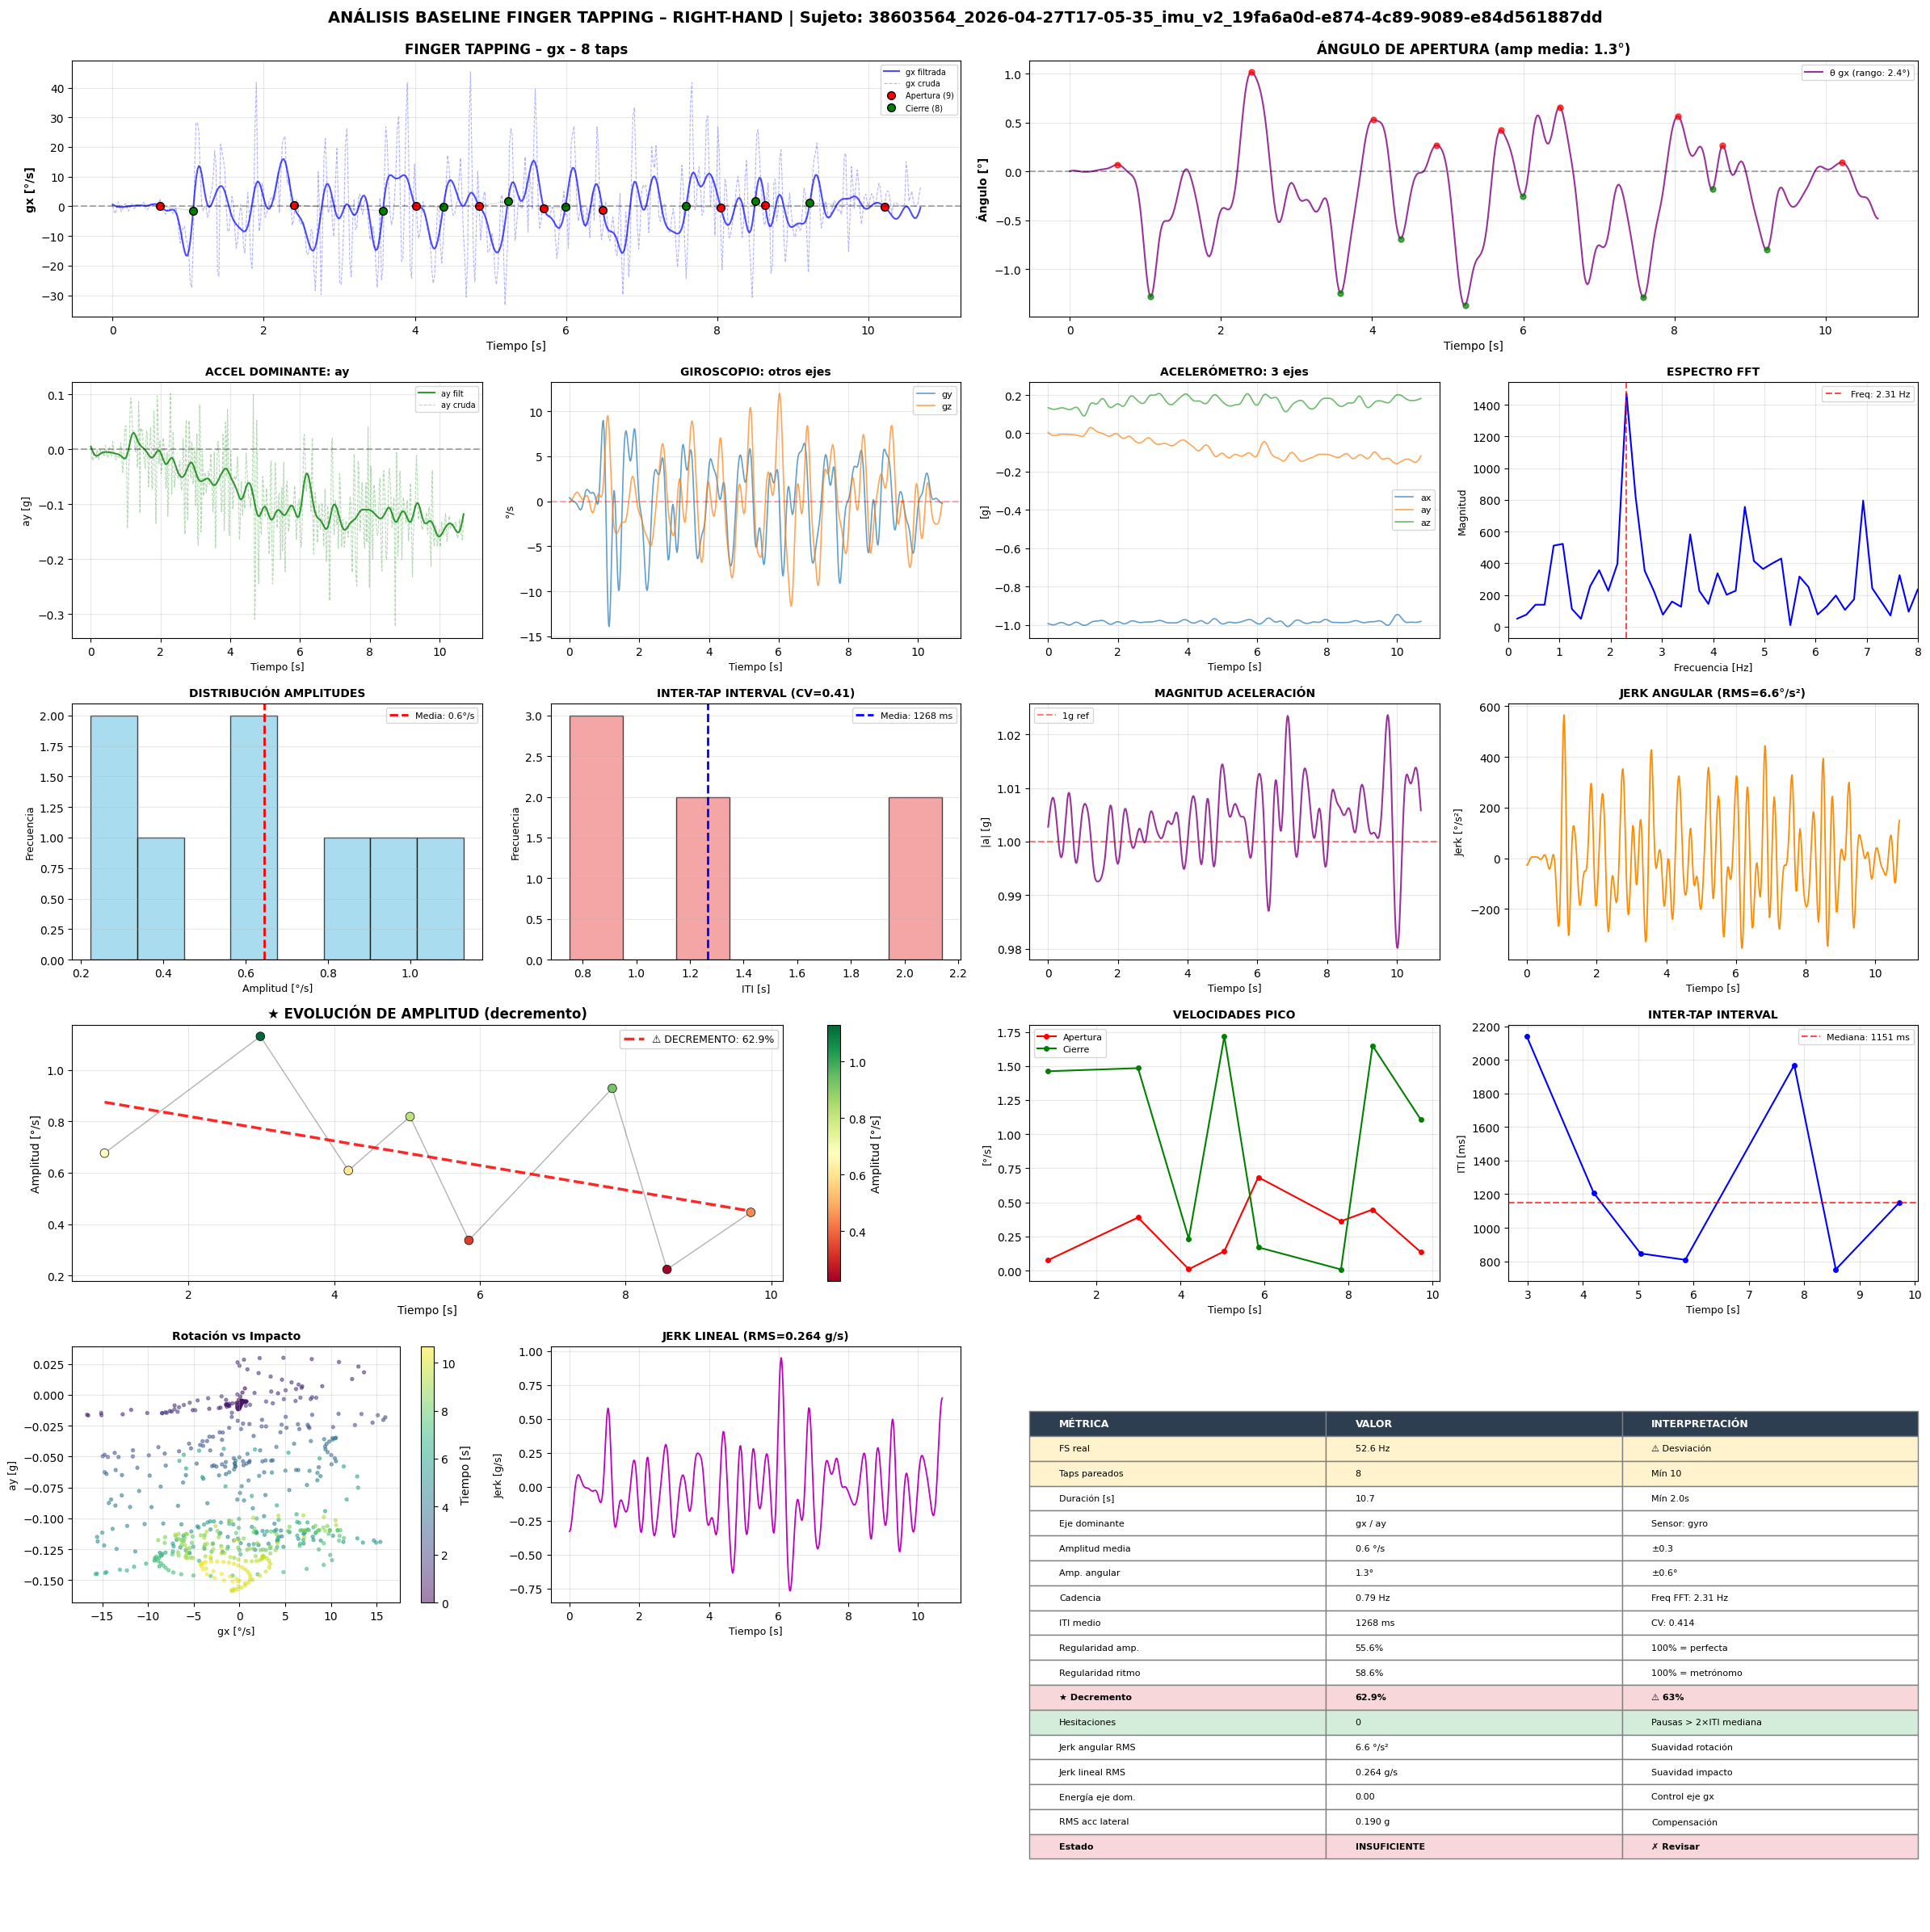

In [2]:
# ========================================
# EJECUCIÓN (baseline Finger Tapping)
# ========================================

# Carpeta con JSONs (por defecto: Score 0)
RUTA_ENTRADA = "./FINGER_TAPPING/Score 0"

# Ajusta según el protocolo / tu dataset
ConfigBaseline.PICO_HEIGHT_FACTOR_POS = 0.03
ConfigBaseline.PICO_HEIGHT_FACTOR_NEG = 0.03
ConfigBaseline.PICO_PROMINENCE_FACTOR = 0.03
ConfigBaseline.PICO_MIN_DISTANCE = 10  # 100ms a 100 Hz, evita doble-tap por rebote
ConfigBaseline.N_CICLOS_ESPERADOS = 10
ConfigBaseline.USAR_TOP_N = True

MODO_DEBUG = False

print("\n⚙️  CONFIGURACIÓN (FINGER TAPPING)")
print(f"   • Ruta entrada   : {RUTA_ENTRADA}")
print(f"   • Debug          : {'ON' if MODO_DEBUG else 'OFF'}")
print(f"   • FS objetivo    : {ConfigBaseline.FS} Hz")
print(f"   • Banda gyro     : {ConfigBaseline.GYRO_LOWCUT}–{ConfigBaseline.GYRO_HIGHCUT} Hz")
print(f"   • Top-N esperados: {ConfigBaseline.N_CICLOS_ESPERADOS} taps")

resultados = procesar_entrada(RUTA_ENTRADA, debug=MODO_DEBUG)

if resultados:
    print("\n" + "=" * 80)
    print("RESUMEN GLOBAL – FINGER TAPPING")
    print("=" * 80)
    total_disp = total_ok = 0
    for r in resultados:
        for vd in r["variables_totales"].values():
            total_disp += 1
            if vd["valido"]:
                total_ok += 1

    print(
        f"Pruebas: {len(resultados)} | Dispositivos: {total_disp} | Válidos: {total_ok} | Inválidos: {total_disp-total_ok}"
    )

    generar_excel_baseline(resultados, ConfigBaseline.OUTPUT_BASE)


In [3]:
import pandas as pd
import numpy as np
import os

# Ajusta a tu carpeta real si difiere de la usada en la celda de Ejecución
carpeta_datos = RUTA_ENTRADA

print(f"Analizando archivos en: {carpeta_datos}\n")

# Re-procesar todos los archivos (o reutilizar 'resultados' si ya existe en memoria)
resultados_completos = resultados if 'resultados' in dir() else []

if not resultados_completos:
    archivos = [os.path.join(carpeta_datos, f)
                for f in os.listdir(carpeta_datos) if f.endswith('.json')]
    for archivo in archivos:
        try:
            r = analisis_baseline_finger_tapping(archivo, debug=False)
            if r:
                resultados_completos.append(r)
        except Exception:
            pass

# ── Extraer métricas de pruebas VÁLIDAS ──────────────────────────────────────
metricas_validas = []

for r in resultados_completos:
    if "variables_totales" not in r:
        continue
    for did, vars_dict in r["variables_totales"].items():
        if vars_dict.get("valido", False):
            metricas_validas.append({
                "Sujeto":                       os.path.basename(r.get("archivo", "")),
                "Mano":                         did,
                "Taps Pareados":                vars_dict.get("n_taps"),
                "Duración (s)":                 vars_dict.get("duracion"),
                "Cadencia (Hz)":                vars_dict.get("cadencia"),
                "ITI Media (s)":                vars_dict.get("iti_media"),
                "ITI Std (s)":                  vars_dict.get("iti_std"),
                "ITI CV":                       vars_dict.get("iti_cv"),
                "Intervalo Medio (s)":          vars_dict.get("intervalo_medio"),
                "Amplitud Media (°/s)":         vars_dict.get("amplitud_media"),
                "Amplitud Estándar (°/s)":      vars_dict.get("amplitud_std"),
                "CV Amplitud":                  vars_dict.get("amplitud_cv"),
                "Amplitud Angular Media (°)":   vars_dict.get("amplitud_angular_media"),
                "Amplitud Angular Estándar (°)": vars_dict.get("amplitud_angular_std"),
                "Rango Angular Total (°)":      vars_dict.get("rango_angular_total"),
                "Velocidad Pico Media (°/s)":   vars_dict.get("velocidad_pico_media"),
                "Velocidad Pico Max (°/s)":     vars_dict.get("velocidad_pico_max"),
                "Velocidad Pico Estándar (°/s)": vars_dict.get("velocidad_pico_std"),
                "Frecuencia Dominante (Hz)":    vars_dict.get("frecuencia"),
                "Regularidad (%)": vars_dict.get("regularidad"),
                "Regularidad Rítmica (%)": vars_dict.get("regularidad_ritmica"),
                "Decremento (%)": vars_dict.get("decremento_pct"),
                "Decremento Pendiente":         vars_dict.get("decremento_pendiente"),
                "Decremento R²":                vars_dict.get("decremento_r2"),
                "N Hesitaciones":               vars_dict.get("n_hesitaciones"),
                "Compensación Lateral":         vars_dict.get("compensacion_lateral"),
                "Rango ωx (°/s)":              vars_dict.get("rango_ωx"),
                "Rango ωy (°/s)":              vars_dict.get("rango_ωy"),
                "Rango ωz (°/s)":              vars_dict.get("rango_ωz"),
                "Jerk Angular RMS (°/s²)":     vars_dict.get("jerk_rms_angular"),
                "Jerk Lineal RMS (g/s)":       vars_dict.get("jerk_rms"),
                "RMS Acc Lateral (g)":          vars_dict.get("rms_acc_lateral"),
                "Energía Relativa":             vars_dict.get("energia_relativa_dom"),
            })

df_validos = pd.DataFrame(metricas_validas)

print(f"\n{'='*80}")
print(f"Total de señales válidas encontradas: {len(df_validos)}")
print(f"{'='*80}\n")

if len(df_validos) > 0:
    cols_numericas = df_validos.select_dtypes(include=[np.number]).columns

    baseline_stats = pd.DataFrame({
        'Media':          df_validos[cols_numericas].mean(),
        'Desv. Est.':     df_validos[cols_numericas].std(),
        'CV (%)':         (df_validos[cols_numericas].std() / df_validos[cols_numericas].mean()) * 100,
        'P_5':            df_validos[cols_numericas].quantile(0.05),
        'P_25':           df_validos[cols_numericas].quantile(0.25),
        'P_50 (Mediana)': df_validos[cols_numericas].median(),
        'P_75':           df_validos[cols_numericas].quantile(0.75),
        'P_95':           df_validos[cols_numericas].quantile(0.95),
    })

    baseline_stats['Rango Normal'] = baseline_stats.apply(
        lambda x: f"[{x['P_5']:.3f} a {x['P_95']:.3f}]", axis=1
    )

    display(baseline_stats.round(3))

    # ── Imprimir rangos de referencia en consola ──────────────────────────
    print("\n" + "="*90)
    print("RANGOS DE REFERENCIA — PACIENTES SANOS (Baseline Estadístico — FINGER TAPPING)")
    print("="*90)
    header = f"{'Métrica':<45} {'Media':>10} {'± DE':>10} {'Mediana':>10}   {'Rango Normal [P5 – P95]'}"
    print(header)
    print("-" * 90)
    for metrica, row in baseline_stats.iterrows():
        rango = f"[{row['P_5']:.3f}  –  {row['P_95']:.3f}]"
        print(f"{metrica:<45} {row['Media']:>10.3f} {row['Desv. Est.']:>10.3f} {row['P_50 (Mediana)']:>10.3f}   {rango}")
    print("="*90)
    print("(Rango Normal = Percentil 5 al 95 de los taps válidos de sujetos sanos)\n")
else:
    print("⚠️ No hay pruebas suficientes o válidas para generar la baseline.")


Analizando archivos en: ./FINGER_TAPPING/Score 0


ANÁLISIS BASELINE COMPLETO: FINGER TAPPING

📁 CARGANDO: 044a504c-3865-4d81-bc98-5c7241b5d145.json
   ✓ Muestras: 1306

🔍 Tipo: Ambas manos (detectada) | Dispositivos: RIGHT-HAND, LEFT-HAND

📊 PROCESANDO 2 DISPOSITIVO(S):

   • LEFT-HAND: 662 muestras
   ✓ Gráfica guardada: 044a504c-3865-4d81-bc98-5c7241b5d145_LEFT-HAND_FT_baseline_DETALLADO.png
     ✓ Taps: 3 | Amplitud: 1.8 °/s | Cadencia: 1.75 Hz
     ✓ ITI: 570 ms (CV=0.991) | Regularidad: 81.8%
     ✓ Decremento: 28.5% ✓ | Hesitaciones: 0
     ✓ Jerk angular: 10.8 °/s² | FS: 100.0 Hz ✓
     ✓ Estado: INSUFICIENTE

   • RIGHT-HAND: 644 muestras
   ✓ Gráfica guardada: 044a504c-3865-4d81-bc98-5c7241b5d145_RIGHT-HAND_FT_baseline_DETALLADO.png
     ✓ Taps: 7 | Amplitud: 1.5 °/s | Cadencia: 1.30 Hz
     ✓ ITI: 769 ms (CV=0.365) | Regularidad: 33.6%
     ✓ Decremento: -136.0% ✓ | Hesitaciones: 0
     ✓ Jerk angular: 14.3 °/s² | FS: 71.4 Hz ⚠️
     ✓ Estado: INSUFICIENTE

💾 Reporte: baseli

,Media,Desv. Est.,CV (%),P_5,P_25,P_50 (Mediana),P_75,P_95,Rango Normal
Taps Pareados,10.000,0.000,0.000,10.000,10.000,10.000,10.000,10.000,[10.000 a 10.000]
Duración (s),8.268,2.248,27.187,5.644,6.595,7.826,9.422,11.553,[5.644 a 11.553]
Cadencia (Hz),1.694,0.484,28.589,1.003,1.355,1.602,1.993,2.428,[1.003 a 2.428]
ITI Media (s),0.650,0.233,35.804,0.412,0.502,0.624,0.738,0.997,[0.412 a 0.997]
ITI Std (s),0.326,0.140,42.866,0.112,0.276,0.304,0.393,0.561,[0.112 a 0.561]
ITI CV,0.523,0.201,38.546,0.182,0.405,0.539,0.628,0.837,[0.182 a 0.837]
Intervalo Medio (s),0.650,0.233,35.804,0.412,0.502,0.624,0.738,0.997,[0.412 a 0.997]
Amplitud Media (°/s),0.991,0.583,58.824,0.344,0.501,0.742,1.492,2.104,[0.344 a 2.104]
Amplitud Estándar (°/s),0.357,0.204,57.210,0.114,0.207,0.306,0.476,0.803,[0.114 a 0.803]
CV Amplitud,0.386,0.131,34.020,0.205,0.288,0.354,0.469,0.644,[0.205 a 0.644]



RANGOS DE REFERENCIA — PACIENTES SANOS (Baseline Estadístico — FINGER TAPPING)
Métrica                                            Media       ± DE    Mediana   Rango Normal [P5 – P95]
------------------------------------------------------------------------------------------
Taps Pareados                                     10.000      0.000     10.000   [10.000  –  10.000]
Duración (s)                                       8.268      2.248      7.826   [5.644  –  11.553]
Cadencia (Hz)                                      1.694      0.484      1.602   [1.003  –  2.428]
ITI Media (s)                                      0.650      0.233      0.624   [0.412  –  0.997]
ITI Std (s)                                        0.326      0.140      0.304   [0.112  –  0.561]
ITI CV                                             0.523      0.201      0.539   [0.182  –  0.837]
Intervalo Medio (s)                                0.650      0.233      0.624   [0.412  –  0.997]
Amplitud Media (°/s)        

Construyendo Baseline Dinámica COMPLETA — FINGER TAPPING...
Total de ciclos válidos procesados: 405


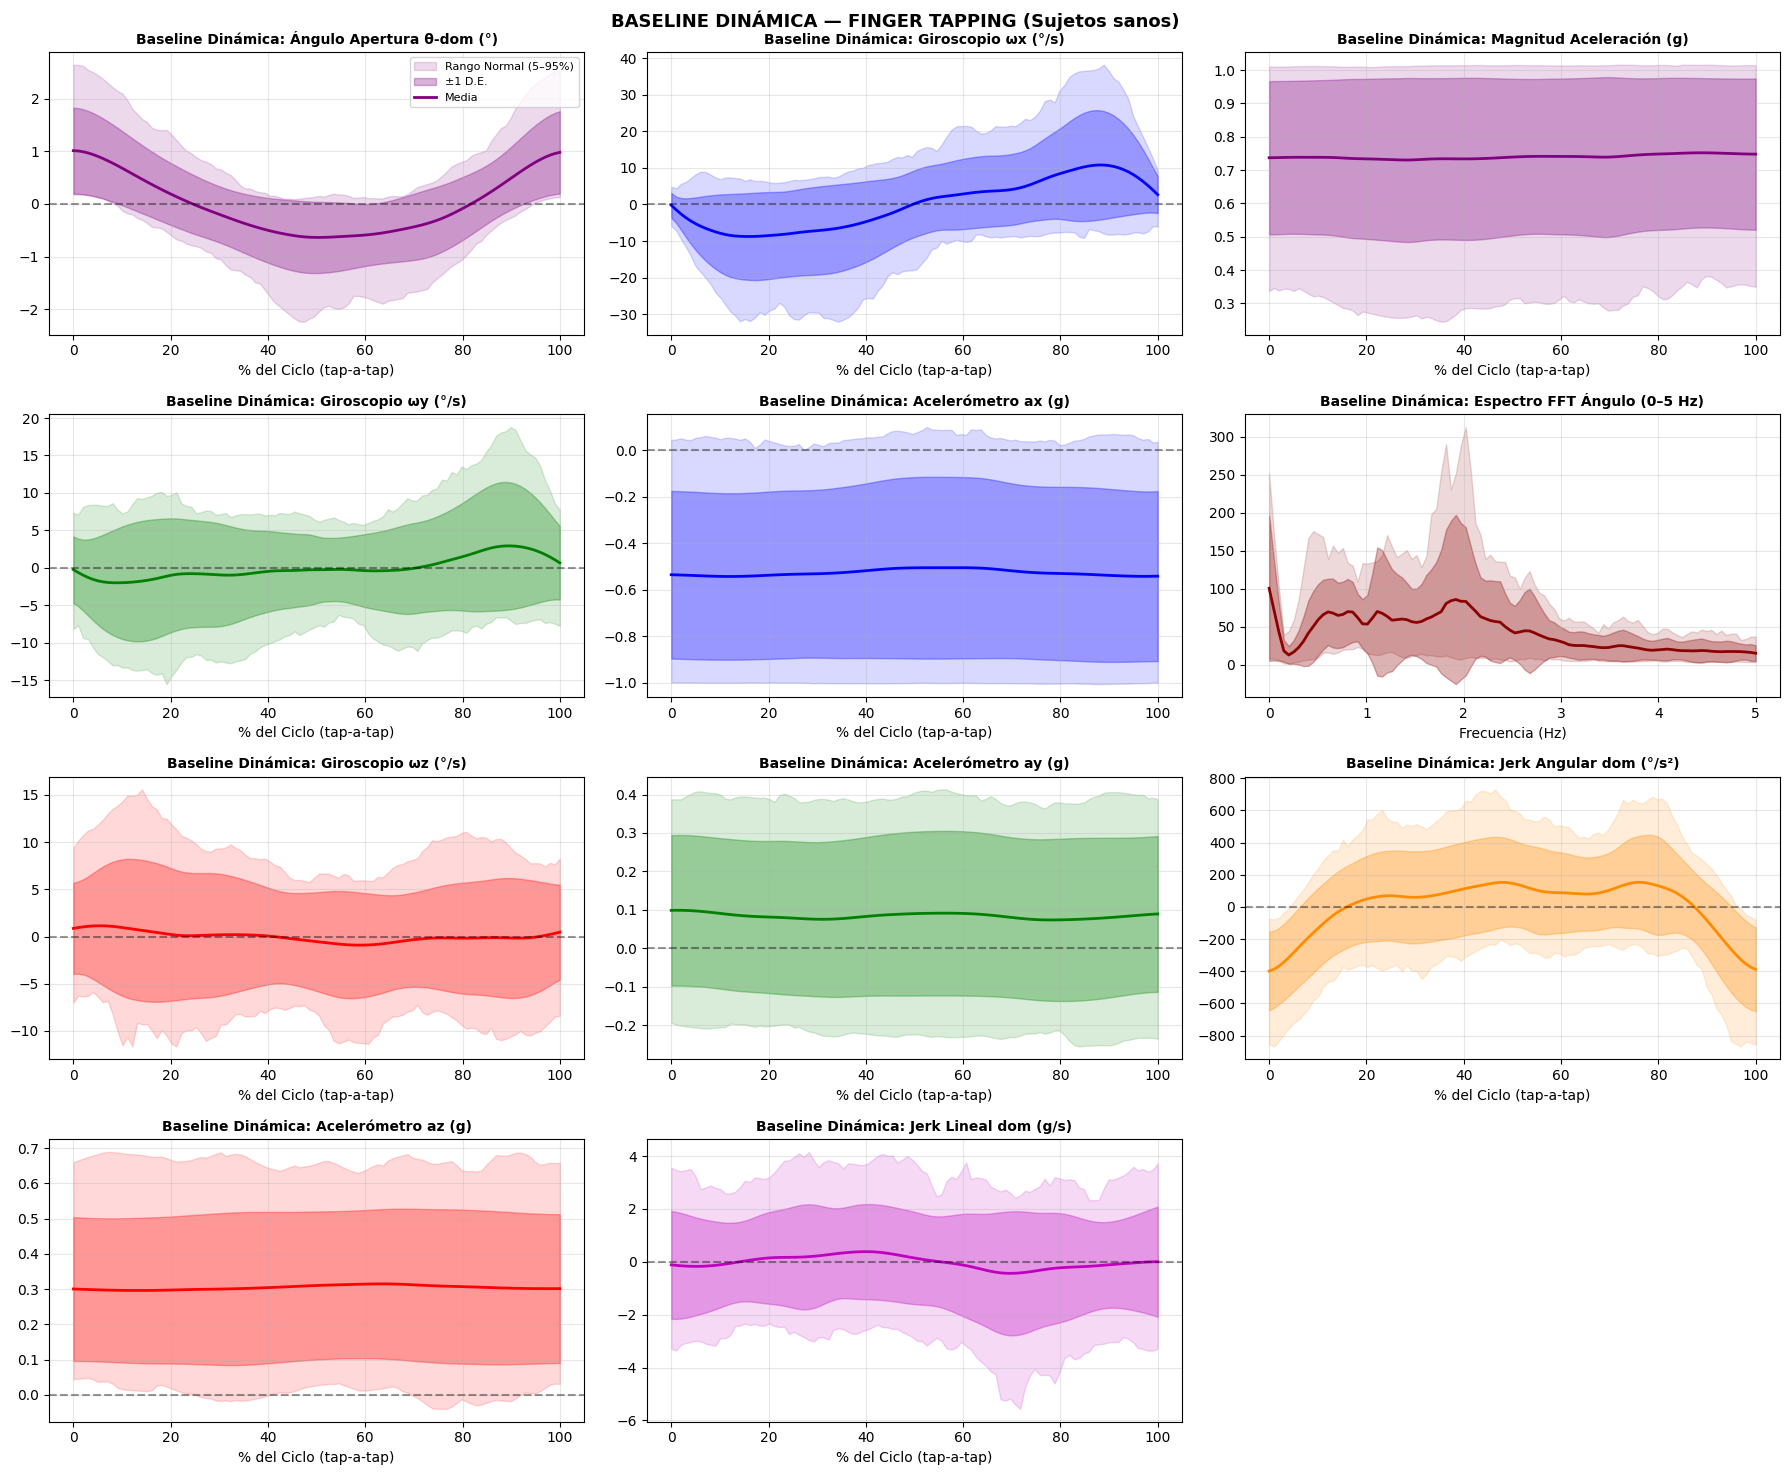


RESUMEN ESTADÍSTICO — CURVAS DE BASELINE DINÁMICA (FINGER TAPPING)
Señal            Media_min  Media_max     DE_min     DE_max   DE_media   CV_media%     P5_min    P95_max
--------------------------------------------------------------------------------------------------------------
gx                  -8.765     10.776      3.357     15.055     10.558      180.39    -32.061     38.184   [% Ciclo]
gy                  -2.007      2.926      4.222      8.557      6.320      583.53    -15.537     18.794   [% Ciclo]
gz                  -0.907      1.141      4.826      7.461      5.875     1417.95    -11.642     15.584   [% Ciclo]
ax                  -0.543     -0.505      0.358      0.391      0.371       70.56     -1.005      0.099   [% Ciclo]
ay                   0.073      0.099      0.196      0.214      0.206      245.27     -0.256      0.413   [% Ciclo]
az                   0.296      0.315      0.203      0.218      0.212       69.66     -0.040      0.689   [% Ciclo]
mag           

In [4]:
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import numpy as np
import os
import pandas as pd
from scipy.fft import fft, fftfreq

print("Construyendo Baseline Dinámica COMPLETA — FINGER TAPPING...")

# Curvas normalizadas a 100 puntos por ciclo (tap-a-tap)
curvas_dict = {
    'gx': [], 'gy': [], 'gz': [],
    'ax': [], 'ay': [], 'az': [], 'mag': [],
    'angulo_dom': [],
    'jerk_ang': [],
    'jerk_lin': [],
    'fft_mag': [],
}

N_PUNTOS = 100
t_norm = np.linspace(0, 100, N_PUNTOS)
f_norm = np.linspace(0, 5, N_PUNTOS)  # Rango FFT 0–5 Hz
dt = 1.0 / 100.0  # FS = 100 Hz

for r in resultados_completos:
    if "variables_totales" not in r:
        continue
    for did, vars_dict in r["variables_totales"].items():
        if not vars_dict.get("valido", False):
            continue

        procesado      = r["resultados"][did]["procesado"]
        picos_pos      = vars_dict["picos_pos"]       # índices de apertura
        eje_gyro_dom   = vars_dict["eje_gyro_dom"]
        eje_accel_dom  = vars_dict["eje_accel_dom"]

        gx, gy, gz    = procesado["gx"], procesado["gy"], procesado["gz"]
        ax, ay, az    = procesado["ax"], procesado["ay"], procesado["az"]
        angulo_dom    = procesado["angulo_dom"]  # ángulo del eje dominante

        mag = np.sqrt(ax**2 + ay**2 + az**2)

        gyro_map  = {"gx": gx, "gy": gy, "gz": gz}
        accel_map = {"ax": ax, "ay": ay, "az": az}

        # Jerk sobre el eje dominante real (no hardcodeado a gx)
        jerk_ang = np.gradient(gyro_map[eje_gyro_dom], dt)
        jerk_lin = np.gradient(accel_map[eje_accel_dom], dt)

        # FFT de la señal de ángulo dominante
        N = len(angulo_dom)
        yf = fft(angulo_dom)
        xf = fftfreq(N, dt)[: N // 2]
        power = np.abs(yf[: N // 2])
        if len(xf) > 1:
            interp_fft = interp1d(xf, power, kind='linear',
                                  bounds_error=False, fill_value=0)
            curvas_dict['fft_mag'].append(interp_fft(f_norm))

        # Segmentar ciclo a ciclo (tap-a-tap: picos_pos[i] → picos_pos[i+1])
        for i in range(len(picos_pos) - 1):
            inicio = picos_pos[i]
            fin    = picos_pos[i + 1]

            if fin <= inicio:
                continue

            x_original = np.linspace(0, 100, fin - inicio)

            senales = [
                ('gx',         gx),
                ('gy',         gy),
                ('gz',         gz),
                ('ax',         ax),
                ('ay',         ay),
                ('az',         az),
                ('mag',        mag),
                ('angulo_dom', angulo_dom),
                ('jerk_ang',   jerk_ang),
                ('jerk_lin',   jerk_lin),
            ]

            for key, signal in senales:
                segmento = signal[inicio:fin]
                interp_func = interp1d(x_original, segmento, kind='cubic')
                norm_sig = interp_func(t_norm)

                # Centrar el ángulo para comparar forma (no nivel absoluto)
                if key == 'angulo_dom':
                    norm_sig = norm_sig - np.mean(norm_sig)

                curvas_dict[key].append(norm_sig)

# Convertir listas a arrays
for k in curvas_dict.keys():
    if len(curvas_dict[k]) > 0:
        curvas_dict[k] = np.array(curvas_dict[k])

if len(curvas_dict.get('angulo_dom', [])) > 0:
    print(f"Total de ciclos válidos procesados: {len(curvas_dict['angulo_dom'])}")

    # Estadísticas por señal
    stats_dict = {}
    for k in curvas_dict.keys():
        if len(curvas_dict[k]) > 0:
            data = curvas_dict[k]
            stats_dict[k] = {
                'mean': np.mean(data, axis=0),
                'std':  np.std(data, axis=0),
                'p5':   np.percentile(data, 5, axis=0),
                'p95':  np.percentile(data, 95, axis=0),
            }

    # ── Gráfica ───────────────────────────────────────────────────────────
    fig, axes = plt.subplots(4, 3, figsize=(18, 15))
    axes = axes.flatten()

    plot_configs = [
        ('angulo_dom', 'Ángulo Apertura θ-dom (°)',        'purple'),
        ('gx',         'Giroscopio ωx (°/s)',              'blue'),
        ('mag',        'Magnitud Aceleración (g)',          'purple'),
        ('gy',         'Giroscopio ωy (°/s)',              'green'),
        ('ax',         'Acelerómetro ax (g)',               'blue'),
        ('fft_mag',    'Espectro FFT Ángulo (0–5 Hz)',     'darkred'),
        ('gz',         'Giroscopio ωz (°/s)',              'red'),
        ('ay',         'Acelerómetro ay (g)',               'green'),
        ('jerk_ang',   'Jerk Angular dom (°/s²)',          'darkorange'),
        ('az',         'Acelerómetro az (g)',               'red'),
        ('jerk_lin',   'Jerk Lineal dom (g/s)',             'm'),
        (None,         '',                                  ''),
    ]

    for i, (key, title, color) in enumerate(plot_configs):
        ax = axes[i]
        if key is None or key not in stats_dict:
            ax.axis('off')
            continue

        m   = stats_dict[key]['mean']
        s   = stats_dict[key]['std']
        p5  = stats_dict[key]['p5']
        p95 = stats_dict[key]['p95']

        x_axis = f_norm if key == 'fft_mag' else t_norm

        ax.fill_between(x_axis, p5, p95,  color=color, alpha=0.15, label='Rango Normal (5–95%)')
        ax.fill_between(x_axis, m - s, m + s, color=color, alpha=0.30, label='±1 D.E.')
        ax.plot(x_axis, m, color=color, lw=2, label='Media')

        if key not in ['mag', 'fft_mag']:
            ax.axhline(0, color='black', ls='--', alpha=0.4)

        ax.set_title(f"Baseline Dinámica: {title}", fontsize=10, fontweight='bold')
        ax.set_xlabel("Frecuencia (Hz)" if key == 'fft_mag' else "% del Ciclo (tap-a-tap)")
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(fontsize=8, loc='upper right')

    plt.suptitle("BASELINE DINÁMICA — FINGER TAPPING (Sujetos sanos)",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Resumen estadístico en consola ────────────────────────────────────
    print("\n" + "="*110)
    print("RESUMEN ESTADÍSTICO — CURVAS DE BASELINE DINÁMICA (FINGER TAPPING)")
    print("="*110)
    print(f"{'Señal':<15} {'Media_min':>10} {'Media_max':>10} {'DE_min':>10} "
          f"{'DE_max':>10} {'DE_media':>10} {'CV_media%':>11} {'P5_min':>10} {'P95_max':>10}")
    print("-"*110)
    for k, s in stats_dict.items():
        etiqueta = "% Ciclo" if k != "fft_mag" else "0-5 Hz"
        de_min   = float(s['std'].min())
        de_max   = float(s['std'].max())
        de_media = float(s['std'].mean())
        media_abs = float(np.mean(np.abs(s['mean'])))
        cv_media  = (de_media / media_abs * 100.0) if media_abs > 0 else 0.0
        print(f"{k:<15} {s['mean'].min():>10.3f} {s['mean'].max():>10.3f} "
              f"{de_min:>10.3f} {de_max:>10.3f} {de_media:>10.3f} {cv_media:>11.2f} "
              f"{s['p5'].min():>10.3f} {s['p95'].max():>10.3f}   [{etiqueta}]")
    print("="*110)
    print("(Valores sobre el eje normalizado de cada señal)\n")
else:
    print("No se encontraron ciclos válidos para generar la baseline dinámica.")


In [5]:
# Exportar JSON unificado: métricas escalares (tabla) + métricas de curvas
# Requiere ejecutar primero la celda de tabla (df_validos) y la de curvas (stats_dict).

import json
from datetime import datetime
from pathlib import Path

if 'df_validos' not in dir() or 'stats_dict' not in dir():
    raise RuntimeError(
        "Primero ejecuta la celda de métricas (df_validos) y la de curvas (stats_dict)."
    )

# Mapeo columnas tabla → claves JSON
metric_map = {
    "Taps Pareados":                 "n_taps",
    "Duración (s)":                  "duracion",
    "Cadencia (Hz)":                 "cadencia",
    "ITI Media (s)":                 "iti_media",
    "ITI Std (s)":                   "iti_std",
    "ITI CV":                        "iti_cv",
    "Intervalo Medio (s)":           "intervalo_medio",
    "Amplitud Media (°/s)":          "amplitud_media",
    "Amplitud Estándar (°/s)":       "amplitud_std",
    "CV Amplitud":                   "amplitud_cv",
    "Amplitud Angular Media (°)":    "amplitud_angular_media",
    "Amplitud Angular Estándar (°)": "amplitud_angular_std",
    "Rango Angular Total (°)":       "rango_angular_total",
    "Velocidad Pico Media (°/s)":    "velocidad_pico_media",
    "Velocidad Pico Max (°/s)":      "velocidad_pico_max",
    "Velocidad Pico Estándar (°/s)": "velocidad_pico_std",
    "Frecuencia Dominante (Hz)":     "frecuencia",
    "Regularidad (%)": "regularidad",
    "Regularidad Rítmica (%)": "regularidad_ritmica",
    "Decremento (%)": "decremento_pct",
    "Decremento Pendiente":          "decremento_pendiente",
    "Decremento R²":                 "decremento_r2",
    "N Hesitaciones":                "n_hesitaciones",
    "Compensación Lateral":          "compensacion_lateral",
    "Rango ωx (°/s)":               "rango_wx",
    "Rango ωy (°/s)":               "rango_wy",
    "Rango ωz (°/s)":               "rango_wz",
    "Jerk Angular RMS (°/s²)":      "jerk_rms_angular",
    "Jerk Lineal RMS (g/s)":        "jerk_rms",
    "RMS Acc Lateral (g)":           "rms_acc_lateral",
    "Energía Relativa":              "energia_relativa_dom",
}

# Mapeo señales de curvas → claves JSON
curve_map = {
    "gx":         "señal_gx",
    "gy":         "señal_gy",
    "gz":         "señal_gz",
    "ax":         "señal_ax",
    "ay":         "señal_ay",
    "az":         "señal_az",
    "mag":        "señal_mag",
    "angulo_dom": "señal_angulo_dom",
    "jerk_ang":   "señal_jerk_ang",
    "jerk_lin":   "señal_jerk_lin",
    "fft_mag":    "señal_fft_mag",
}

payload = {
    "_meta": {
        "description": (
            "Baseline estadística de sujetos sanos para la prueba de "
            "Finger Tapping (MDS-UPDRS 3.4)."
        ),
        "fuente": "fingertapping.ipynb",
        "formato": (
            "Cada métrica contiene: mean, std, p5, p95 "
            "(P5 y P95 definen el rango normal)"
        ),
        "generado": datetime.now().isoformat(),
    },
}

# 1) Métricas escalares
for col_name, out_key in metric_map.items():
    if col_name not in df_validos.columns:
        continue
    col = df_validos[col_name].dropna().astype(float)
    if col.empty:
        continue
    payload[out_key] = {
        "mean": float(col.mean()),
        "std":  float(col.std()),
        "p5":   float(col.quantile(0.05)),
        "p95":  float(col.quantile(0.95)),
    }

# 2) Métricas de curvas
payload["_meta_señales"] = (
    "Envolventes de señal derivadas de curvas baseline dinámicas. "
    "Para cada señal: mean=(Media_min+Media_max)/2, std=DE_media, "
    "p5=P5_min, p95=P95_max."
)

for curve_key, out_key in curve_map.items():
    if curve_key not in stats_dict:
        continue
    s = stats_dict[curve_key]
    mean_arr = s["mean"]
    std_arr  = s["std"]
    p5_arr   = s["p5"]
    p95_arr  = s["p95"]

    payload[out_key] = {
        "mean": float((float(mean_arr.min()) + float(mean_arr.max())) / 2.0),
        "std":  float(std_arr.mean()),
        "p5":   float(p5_arr.min()),
        "p95":  float(p95_arr.max()),
    }

# Guardar JSON
output_path = Path("./Finger Tapping/baseline/summary/finger_tapping_baseline_full.json")
output_path.parent.mkdir(parents=True, exist_ok=True)

with output_path.open("w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2, ensure_ascii=False)

print(f"JSON exportado en: {output_path.resolve()}")

n_escalares = len([k for k in payload if not k.startswith('_') and not k.startswith('señal_')])
n_curvas    = len([k for k in payload if k.startswith('señal_')])
print(f"Métricas escalares exportadas : {n_escalares}")
print(f"Métricas de curvas exportadas : {n_curvas}")


JSON exportado en: C:\Universidad\Semestre IX\PDG II\datosBaseline\Finger Tapping\baseline\summary\finger_tapping_baseline_full.json
Métricas escalares exportadas : 31
Métricas de curvas exportadas : 11


## Ejecución

Esta celda corre el baseline sobre todos los `.json` de `RUTA_ENTRADA` y genera el Excel resumen.
